In [17]:
%pip install numba

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aeon 1.3.0 requires pandas<2.4.0,>=2.0.0, but you have pandas 3.0.0 which is incompatible.
aeon 1.3.0 requires scikit-learn<1.8.0,>=1.0.0, but you have scikit-learn 1.8.0 which is incompatible.
aeon 1.3.0 requires scipy<1.16.0,>=1.9.0, but you have scipy 1.17.0 which is incompatible.
tslearn 0.6.4 requires scikit-learn<1.7,>=1.3.2, but you have scikit-learn 1.8.0 which is incompatible.
tslearn 0.6.4 requires scipy<1.17,>=1.10.1, but you have scipy 1.17.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import polars as pl

parquet_path = r"C:\Users\wongb\Downloads\ratings-20260117-20260217.parquet"
df = pl.read_parquet(parquet_path)
df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification
i64,i64,str,str,datetime[ms],datetime[ms],datetime[ms],str,bool
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…",2021-02-04 10:08:21.128,2021-02-04 11:46:40.544,2026-02-01 14:36:13.314,"""NOT_HELPFUL""",false
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…",2021-02-04 10:08:21.128,2021-02-04 12:00:19.835,2026-02-01 14:36:04.345,"""NOT_HELPFUL""",false
1358604958673719296,1358464064322691078,"""456D1C422BA1A09690B986C8A1DBE7…","""FAB1117EE31D648BA7C11062F626AF…",2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 08:56:34.712,"""NOT_HELPFUL""",false
1358604958673719296,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""FAB1117EE31D648BA7C11062F626AF…",2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 00:51:34.502,"""NOT_HELPFUL""",false
1358844963216326659,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""605A405C64CC57A943D086CC80E5AC…",2021-02-07 17:14:06.633,2021-02-08 18:27:40.007,2026-02-09 00:51:18.076,"""NOT_HELPFUL""",false
…,…,…,…,…,…,…,…,…
1873623034814238798,1873417011294093499,"""C6C2E0DD1A03ADE2BC4C0F1870E01E…","""27AC2BCC9AF39C20C5ECC5D5A45F32…",2024-12-29 17:13:16.554,2024-12-30 06:51:56.390,2026-02-14 01:57:17.194,"""HELPFUL""",false
1873640928910692708,1873299604080607330,"""E26C94838DB911EDA747183982B930…","""7F16863BE3FB87264952B6B64F8082…",2024-12-29 09:26:44.493,2024-12-30 08:03:02.674,2026-02-14 20:22:12.656,"""NOT_HELPFUL""",false
1873642906235351150,1873299604080607330,"""E26C94838DB911EDA747183982B930…","""BE38D44A6D5F6828EE25798913696D…",2024-12-29 09:26:44.493,2024-12-30 08:10:54.106,2026-02-14 20:22:02.614,"""NOT_HELPFUL""",false


In [3]:
ratings_preprocessed_df = (
    df
    .with_columns(
        pl.col("ratingCreatedAt")
        .cast(pl.Datetime, strict=False)
        .alias("ratingCreatedAt_ts")
    )
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
    .with_columns(
        pl.col("ratingCreatedAt_ts")
        .diff()
        .over("raterParticipantId")
        .dt.total_seconds()
        .alias("delta_seconds")
    )
    .with_columns(
        pl.when(pl.col("delta_seconds") > 0)
        .then(pl.col("delta_seconds").log())
        .otherwise(None)
        .alias("log_delta_seconds")
    )
)

ratings_preprocessed_df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds
i64,i64,str,str,datetime[ms],datetime[ms],datetime[ms],str,bool,datetime[μs],i64,f64
2016534713742061788,2016246745739546987,"""00002C7FD6E0080A69D0AB879C3D9B…","""FD7979DE7F187DC14A4FDF8F557242…",2026-01-27 20:27:38.894,2026-01-28 15:31:55.816,2026-01-28 20:47:22.321,"""HELPFUL""",false,2026-01-28 20:47:22.321,null,null
2017641230612451495,2017578816177111423,"""00002C7FD6E0080A69D0AB879C3D9B…","""2CE75633DDBFF074EE77E7DC582D7B…",2026-01-31 12:40:49.235,2026-01-31 16:48:49.996,2026-01-31 17:21:23.365,"""HELPFUL""",false,2026-01-31 17:21:23.365,246841,12.4165
2018404224149717157,2018387895459983768,"""00002C7FD6E0080A69D0AB879C3D9B…","""54F0002E8A4890D64140C45F5D108C…",2026-02-02 18:15:48.768,2026-02-02 19:20:41.831,2026-02-02 22:44:01.605,"""HELPFUL""",false,2026-02-02 22:44:01.605,192158,12.166073
2012648760455671942,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""B5A7C39C8965D9D8AF5CC38B994AAC…",2026-01-17 18:02:30.876,2026-01-17 22:10:32.357,2026-01-18 15:41:27.835,"""NOT_HELPFUL""",false,2026-01-18 15:41:27.835,null,null
2012693431319990371,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""D174DF64F45A03029780F273B4335C…",2026-01-17 18:02:30.876,2026-01-18 01:08:02.720,2026-01-18 15:44:04.360,"""HELPFUL""",false,2026-01-18 15:44:04.360,156,5.049856
…,…,…,…,…,…,…,…,…,…,…,…
2020752418963669036,2020604630657302841,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""BA48B1306E38D71468370309229E18…",2026-02-08 21:04:19.624,2026-02-09 06:51:35.102,2026-02-09 08:02:06.384,"""NOT_HELPFUL""",false,2026-02-09 08:02:06.384,1041422,13.856098
2021916824426701208,2021784932818067904,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""E6ABEA01CD00795F7897A1245141FF…",2026-02-12 03:14:25.588,2026-02-12 11:58:30.999,2026-02-12 15:50:43.969,"""HELPFUL""",false,2026-02-12 15:50:43.969,287317,12.568341
2019488960465031197,2019467286298472468,"""FFFFC46B8555A97065DB39F7D600C8…","""8D8A300EC055D96FC685C886688785…",2026-02-05 17:44:55.598,2026-02-05 19:11:03.122,2026-02-06 08:34:11.398,"""HELPFUL""",false,2026-02-06 08:34:11.398,null,null


In [58]:
ratings_per_user = (
    ratings_preprocessed_df
    .group_by("raterParticipantId")
    .agg(pl.len().alias("ratings_count"))
)

summary_stats_df = ratings_preprocessed_df.select(
    pl.len().alias("total_ratings"),
    pl.col("raterParticipantId").n_unique().alias("total_users"),
    pl.lit(ratings_per_user["ratings_count"].mean()).alias("avg_ratings_per_user"),
    pl.col("delta_seconds").mean().alias("avg_time_gap_seconds"),
    pl.col("delta_seconds").median().alias("median_time_gap_seconds"),
    pl.col("log_delta_seconds").mean().alias("avg_log_time_gap"),
    pl.col("log_delta_seconds").median().alias("median_log_time_gap"),
)

summary_stats_df

total_ratings,total_users,avg_ratings_per_user,avg_time_gap_seconds,median_time_gap_seconds,avg_log_time_gap,median_log_time_gap
u32,u32,f64,f64,f64,f64,f64
6499635,484059,13.427361,83461.493586,2012.0,7.165669,7.607878


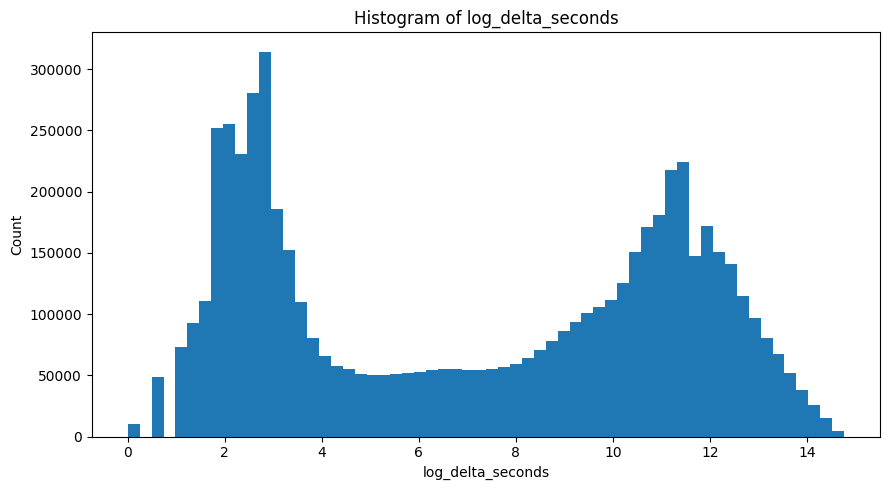

In [59]:
import matplotlib.pyplot as plt

if "ratings_preprocessed_df" not in globals():
    raise ValueError("`ratings_preprocessed_df` not found. Run Cell 3 first.")

values = (
    ratings_preprocessed_df
    .select("log_delta_seconds")
    .drop_nulls()
    .to_series()
    .to_numpy()
 )

plt.figure(figsize=(9, 5))
plt.hist(values, bins=60)
plt.title("Histogram of log_delta_seconds")
plt.xlabel("log_delta_seconds")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [60]:
import numpy as np
import polars as pl
from hmmlearn.hmm import GaussianHMM
from tqdm.auto import tqdm

# -----------------------------
# Run configuration (edit these)
# -----------------------------
SAMPLE_MODE = False
SAMPLE_RATERS = 100000
RANDOM_SEED = 42
HMM_MAX_ITER = 50

if "ratings_preprocessed_df" not in globals():
    if "df" not in globals():
        raise ValueError("`df` not found. Run Cell 2 first to load your parquet data.")

    ratings_preprocessed_df = (
        df
        .with_columns(
            pl.col("ratingCreatedAt")
            .cast(pl.Datetime, strict=False)
            .alias("ratingCreatedAt_ts")
        )
        .sort(["raterParticipantId", "ratingCreatedAt_ts"])
        .with_columns(
            pl.col("ratingCreatedAt_ts")
            .diff()
            .over("raterParticipantId")
            .dt.total_seconds()
            .alias("delta_seconds")
        )
        .with_columns(
            pl.when(pl.col("delta_seconds") > 0)
            .then(pl.col("delta_seconds").log())
            .otherwise(None)
            .alias("log_delta_seconds")
        )
    )

progress = tqdm(total=7, desc="Session labeling", unit="step")

working_df = ratings_preprocessed_df
progress.set_postfix_str("choose data scope")

if SAMPLE_MODE:
    unique_raters_df = working_df.select("raterParticipantId").unique()
    total_raters = unique_raters_df.height
    n_sample = min(SAMPLE_RATERS, total_raters)
    sampled_raters = unique_raters_df.sample(
        n=n_sample, seed=RANDOM_SEED, shuffle=True
    )["raterParticipantId"].to_list()
    working_df = working_df.filter(pl.col("raterParticipantId").is_in(sampled_raters))
    print(f"SAMPLE_MODE=True -> using {n_sample} raters out of {total_raters}")
else:
    print("SAMPLE_MODE=False -> using all raters")
progress.update(1)

progress.set_postfix_str("sort + row index")
hmm_input_df = (
    working_df
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
    .with_row_index("row_nr")
)
progress.update(1)

progress.set_postfix_str("build observations")
valid_obs_df = hmm_input_df.filter(pl.col("log_delta_seconds").is_not_null())
if valid_obs_df.height == 0:
    raise ValueError("No valid non-null log_delta_seconds observations found.")

X = valid_obs_df["log_delta_seconds"].to_numpy().reshape(-1, 1)
progress.update(1)

progress.set_postfix_str("compute sequence lengths")
lengths = (
    valid_obs_df
    .group_by("raterParticipantId", maintain_order=True)
    .agg(pl.len().alias("n"))["n"]
    .to_list()
)
if len(lengths) == 0:
    raise ValueError("No user sequences found for HMM fitting.")
progress.update(1)

progress.set_postfix_str("fit HMM")
hmm = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=HMM_MAX_ITER,
    random_state=RANDOM_SEED,
)
hmm.fit(X, lengths=lengths)
progress.update(1)

progress.set_postfix_str("decode states")
decoded_states = hmm.predict(X, lengths=lengths)
state_means = hmm.means_.flatten()
in_session_state = int(np.argmin(state_means))
in_session_binary = (decoded_states == in_session_state).astype(np.int8)
progress.update(1)

progress.set_postfix_str("map to events")
state_df = pl.DataFrame({
    "row_nr": valid_obs_df["row_nr"],
    "in_session_prev_gap": in_session_binary,
})

ratings_session_df = (
    hmm_input_df
    .join(state_df, on="row_nr", how="left")

    # Step 1: promote session-starters
    # A rating with a large gap (null or 0) should be in_session=1
    # if the NEXT rating has a small gap (in_session_prev_gap=1),
    # meaning this rating started a session that continued
    .with_columns(
        pl.col("in_session_prev_gap")
        .shift(-1)
        .over("raterParticipantId")
        .alias("next_gap_in_session")
    )
    .with_columns(
        pl.when(
            (pl.col("in_session_prev_gap") == 1) |  # continuation: small gap back
            (pl.col("next_gap_in_session") == 1)     # session-starter: small gap forward
        )
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .cast(pl.Int8)
        .alias("in_session")
    )

    # Step 2: remove singletons
    # A rating is truly isolated if both neighbors are 0 — not a real session
    .with_columns([
        pl.col("in_session").shift(1).over("raterParticipantId").fill_null(0).alias("prev_in_session"),
        pl.col("in_session").shift(-1).over("raterParticipantId").fill_null(0).alias("next_in_session"),
    ])
    .with_columns(
        pl.when(
            (pl.col("in_session") == 1) &
            (pl.col("prev_in_session") == 0) &
            (pl.col("next_in_session") == 0)
        )
        .then(pl.lit(0))
        .otherwise(pl.col("in_session"))
        .cast(pl.Int8)
        .alias("in_session")
    )
    .drop(["row_nr", "in_session_prev_gap", "next_gap_in_session", "prev_in_session", "next_in_session"])
)
progress.update(1)
progress.close()

print("HMM state means:", state_means)
print("In-session state index:", in_session_state)

ratings_session_df

Session labeling:   0%|          | 0/7 [00:00<?, ?step/s]

SAMPLE_MODE=False -> using all raters


KeyboardInterrupt: 

In [38]:
ratings_session_df.write_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\HMM_raw.csv")

In [61]:
ratings_session_df = pl.read_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\HMM_raw.csv")
ratings_session_df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session
i64,i64,str,str,str,str,str,str,bool,str,i64,f64,i64
2016534713742061788,2016246745739546987,"""00002C7FD6E0080A69D0AB879C3D9B…","""FD7979DE7F187DC14A4FDF8F557242…","""2026-01-27T20:27:38.894""","""2026-01-28T15:31:55.816""","""2026-01-28T20:47:22.321""","""HELPFUL""",false,"""2026-01-28T20:47:22.321000""",null,null,0
2017641230612451495,2017578816177111423,"""00002C7FD6E0080A69D0AB879C3D9B…","""2CE75633DDBFF074EE77E7DC582D7B…","""2026-01-31T12:40:49.235""","""2026-01-31T16:48:49.996""","""2026-01-31T17:21:23.365""","""HELPFUL""",false,"""2026-01-31T17:21:23.365000""",246841,12.4165,0
2018404224149717157,2018387895459983768,"""00002C7FD6E0080A69D0AB879C3D9B…","""54F0002E8A4890D64140C45F5D108C…","""2026-02-02T18:15:48.768""","""2026-02-02T19:20:41.831""","""2026-02-02T22:44:01.605""","""HELPFUL""",false,"""2026-02-02T22:44:01.605000""",192158,12.166073,0
2012648760455671942,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""B5A7C39C8965D9D8AF5CC38B994AAC…","""2026-01-17T18:02:30.876""","""2026-01-17T22:10:32.357""","""2026-01-18T15:41:27.835""","""NOT_HELPFUL""",false,"""2026-01-18T15:41:27.835000""",null,null,0
2012693431319990371,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""D174DF64F45A03029780F273B4335C…","""2026-01-17T18:02:30.876""","""2026-01-18T01:08:02.720""","""2026-01-18T15:44:04.360""","""HELPFUL""",false,"""2026-01-18T15:44:04.360000""",156,5.049856,0
…,…,…,…,…,…,…,…,…,…,…,…,…
2020752418963669036,2020604630657302841,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""BA48B1306E38D71468370309229E18…","""2026-02-08T21:04:19.624""","""2026-02-09T06:51:35.102""","""2026-02-09T08:02:06.384""","""NOT_HELPFUL""",false,"""2026-02-09T08:02:06.384000""",1041422,13.856098,0
2021916824426701208,2021784932818067904,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""E6ABEA01CD00795F7897A1245141FF…","""2026-02-12T03:14:25.588""","""2026-02-12T11:58:30.999""","""2026-02-12T15:50:43.969""","""HELPFUL""",false,"""2026-02-12T15:50:43.969000""",287317,12.568341,0
2019488960465031197,2019467286298472468,"""FFFFC46B8555A97065DB39F7D600C8…","""8D8A300EC055D96FC685C886688785…","""2026-02-05T17:44:55.598""","""2026-02-05T19:11:03.122""","""2026-02-06T08:34:11.398""","""HELPFUL""",false,"""2026-02-06T08:34:11.398000""",null,null,0


In [62]:
if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run Cell 5 first.")

import polars as pl

# 1) Overall label distribution
label_counts_df = (
    ratings_session_df
    .group_by("in_session")
    .agg(pl.len().alias("n"))
    .sort("in_session")
)

total_rows = ratings_session_df.height
in_session_rows = label_counts_df.filter(pl.col("in_session") == 1).select(pl.col("n").sum()).item() or 0
in_session_rate = in_session_rows / total_rows if total_rows else 0.0

# 2) Per-user stats
per_user_df = (
    ratings_session_df
    .group_by("raterParticipantId")
    .agg(
        pl.len().alias("n_events"),
        pl.col("in_session").sum().alias("n_in_session"),
    )
    .with_columns(
        (pl.col("n_in_session") / pl.col("n_events")).alias("in_session_rate"),
        (pl.col("n_in_session") > 0).cast(pl.Int8).alias("has_any_in_session"),
        (pl.col("n_in_session") == pl.col("n_events")).cast(pl.Int8).alias("all_events_in_session"),
    )
    .sort("n_events", descending=True)
)

n_users = per_user_df.height
n_users_any_in = per_user_df.filter(pl.col("has_any_in_session") == 1).height
n_users_none_in = per_user_df.filter(pl.col("has_any_in_session") == 0).height
n_users_all_in = per_user_df.filter(pl.col("all_events_in_session") == 1).height

avg_user_in_rate = per_user_df.select(pl.col("in_session_rate").mean()).item()
median_user_in_rate = per_user_df.select(pl.col("in_session_rate").median()).item()

user_rate_quantiles_df = per_user_df.select(
    pl.col("in_session_rate").quantile(0.10).alias("p10"),
    pl.col("in_session_rate").quantile(0.25).alias("p25"),
    pl.col("in_session_rate").quantile(0.50).alias("p50"),
    pl.col("in_session_rate").quantile(0.75).alias("p75"),
    pl.col("in_session_rate").quantile(0.90).alias("p90"),
)

user_mix_summary_df = pl.DataFrame(
    {
        "metric": [
            "n_users",
            "n_users_any_in_session",
            "n_users_no_in_session",
            "n_users_all_in_session",
            "share_users_any_in_session",
            "share_users_no_in_session",
            "share_users_all_in_session",
            "avg_user_in_session_rate",
            "median_user_in_session_rate",
        ],
        "value": [
            float(n_users),
            float(n_users_any_in),
            float(n_users_none_in),
            float(n_users_all_in),
            (n_users_any_in / n_users) if n_users else 0.0,
            (n_users_none_in / n_users) if n_users else 0.0,
            (n_users_all_in / n_users) if n_users else 0.0,
            float(avg_user_in_rate) if avg_user_in_rate is not None else 0.0,
            float(median_user_in_rate) if median_user_in_rate is not None else 0.0,
        ],
    }
)

# 3) First-event fallback sanity: how many first events ended up as in_session=1
first_event_df = (
    ratings_session_df
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
    .group_by("raterParticipantId", maintain_order=True)
    .first()
    .select("raterParticipantId", "in_session")
)

first_event_summary_df = first_event_df.select(
    pl.len().alias("n_users"),
    pl.col("in_session").sum().alias("n_first_event_in_session"),
    (pl.col("in_session").sum() / pl.len()).alias("first_event_in_session_rate"),
)

print(f"Rows: {total_rows:,}")
print(f"In-session rows: {in_session_rows:,} ({in_session_rate:.2%})")

print("\nLabel counts:")
display(label_counts_df)

print("\nRater-level summary:")
display(user_mix_summary_df)

print("\nRater in-session-rate quantiles:")
display(user_rate_quantiles_df)

print("\nFirst-event sanity:")
display(first_event_summary_df)

print("\nTop 10 users by number of events:")
display(per_user_df.head(10))

Rows: 6,499,635
In-session rows: 3,672,984 (56.51%)

Label counts:


in_session,n
i64,u32
0,2826651
1,3672984



Rater-level summary:


metric,value
str,f64
"""n_users""",484059.0
"""n_users_any_in_session""",239788.0
"""n_users_no_in_session""",244271.0
"""n_users_all_in_session""",32687.0
"""share_users_any_in_session""",0.495369
"""share_users_no_in_session""",0.504631
"""share_users_all_in_session""",0.067527
"""avg_user_in_session_rate""",0.297398
"""median_user_in_session_rate""",0.0



Rater in-session-rate quantiles:


p10,p25,p50,p75,p90
f64,f64,f64,f64,f64
0.0,0.0,0.0,0.6,0.833333



First-event sanity:


n_users,n_first_event_in_session,first_event_in_session_rate
u32,i64,f64
484059,103013,0.212811



Top 10 users by number of events:


raterParticipantId,n_events,n_in_session,in_session_rate,has_any_in_session,all_events_in_session
str,u32,i64,f64,i8,i8
"""2E795F3F64D631134231C18AF09756…",4028,3785,0.939672,1,0
"""14D7F5065E2F8F53F72F5325579AE2…",3582,3089,0.862367,1,0
"""0955AA84D076DBBD3981330BF71BBD…",3438,3418,0.994183,1,0
"""E26C94838DB911EDA747183982B930…",3409,3334,0.977999,1,0
"""E848DB71A10D211C7BC9CC031153C0…",3223,3176,0.985417,1,0
"""63B2C1FDD74AB973B3E178B14056D5…",2607,2501,0.95934,1,0
"""A966340CA53AB1FE51516422935AF2…",2409,2338,0.970527,1,0
"""D7FBAE9F9803A0FB30357F139CCEC8…",2388,2117,0.886516,1,0
"""21DE740A6FDA486DCD56C8747D6760…",2162,2063,0.954209,1,0


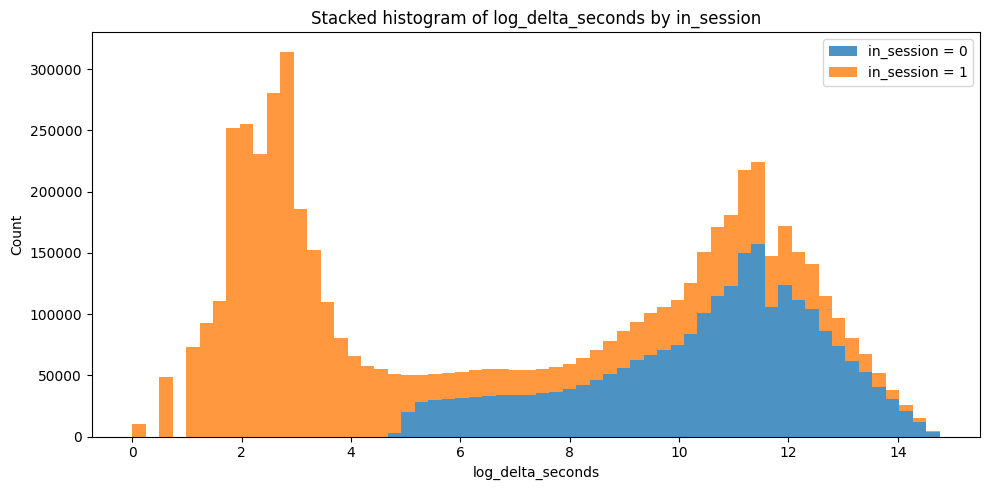

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run the session-labeling cell first.")

plot_df = ratings_session_df.select(["log_delta_seconds", "in_session"]).drop_nulls()

vals_0 = (
    plot_df
    .filter(pl.col("in_session") == 0)
    .select("log_delta_seconds")
    .to_series()
    .to_numpy()
 )
vals_1 = (
    plot_df
    .filter(pl.col("in_session") == 1)
    .select("log_delta_seconds")
    .to_series()
    .to_numpy()
 )

all_vals = np.concatenate([vals_0, vals_1]) if len(vals_0) and len(vals_1) else (vals_0 if len(vals_0) else vals_1)
bins = np.histogram_bin_edges(all_vals, bins=60)

plt.figure(figsize=(10, 5))
plt.hist([vals_0, vals_1], bins=bins, stacked=True, alpha=0.8, label=["in_session = 0", "in_session = 1"])
plt.title("Stacked histogram of log_delta_seconds by in_session")
plt.xlabel("log_delta_seconds")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
import polars as pl

if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run Cell 6 first.")

base_df = ratings_session_df

if "ratingCreatedAt_ts" in base_df.columns:
    time_col = "ratingCreatedAt_ts"
    base_df = base_df.with_columns(pl.col(time_col).cast(pl.Datetime, strict=False))
elif "ratingCreatedAt" in base_df.columns:
    time_col = "ratingCreatedAt"
    base_df = base_df.with_columns(pl.col(time_col).cast(pl.Datetime, strict=False))
else:
    raise ValueError("Need either `ratingCreatedAt_ts` or `ratingCreatedAt` to order events chronologically.")

if "in_session" not in base_df.columns:
    raise ValueError("`in_session` column not found in dataset.")

session_labeled_df = (
    base_df
    .sort(["raterParticipantId", time_col])
    .with_columns(
        pl.col("in_session").cast(pl.Int8).alias("in_session")
    )
    .with_columns(
        (
            (pl.col("in_session") == 1)
            & (pl.col("in_session").shift(1).over("raterParticipantId").fill_null(0) == 0)
        )
        .cast(pl.Int32)
        .alias("session_start")
    )
    .with_columns(
        pl.col("session_start")
        .cum_sum()
        .over("raterParticipantId")
        .alias("user_session_id")
    )
    .with_columns(
        pl.when(pl.col("in_session") == 1)
        .then(pl.col("user_session_id"))
        .otherwise(None)
        .alias("user_session_id")
    )
    .drop("session_start")
)

session_labeled_df.select(
    "raterParticipantId",
    time_col,
    "in_session",
    "user_session_id",
).head(30)

raterParticipantId,ratingCreatedAt_ts,in_session,user_session_id
str,datetime[μs],i8,i32
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-01-28 20:47:22.321,0,null
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-01-31 17:21:23.365,0,null
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-02-02 22:44:01.605,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-18 15:41:27.835,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-18 15:44:04.360,0,null
…,…,…,…
"""00003D7D222733AE9D37A25B930204…",2026-01-27 20:43:33.059,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-27 22:02:16.493,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-30 18:16:23.230,0,null


Headline metrics:


metric,value
str,f64
"""n_users""",484059.0
"""n_users_with_sessions""",239788.0
"""share_users_with_sessions""",0.495369
"""total_sessions""",759000.0
"""n_singleton_sessions""",0.0
"""share_singleton_sessions""",0.0
"""avg_sessions_per_user""",1.567991
"""median_sessions_per_user""",0.0
"""avg_session_length_events""",4.839241


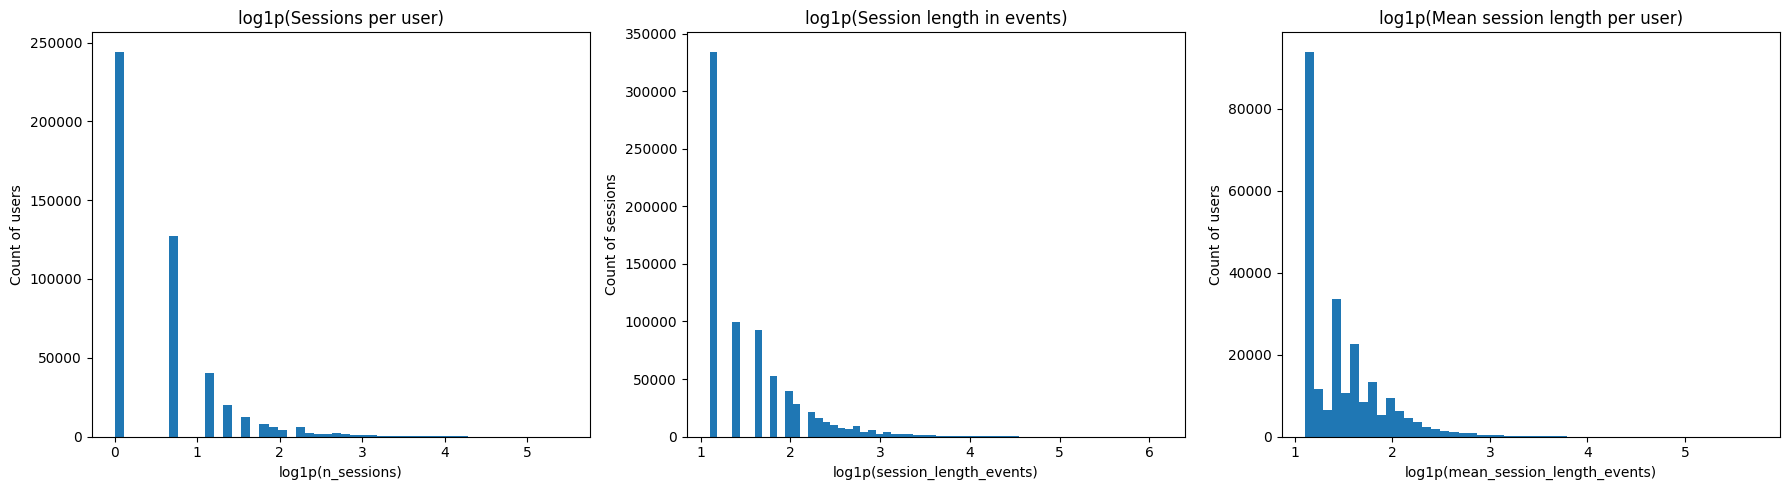

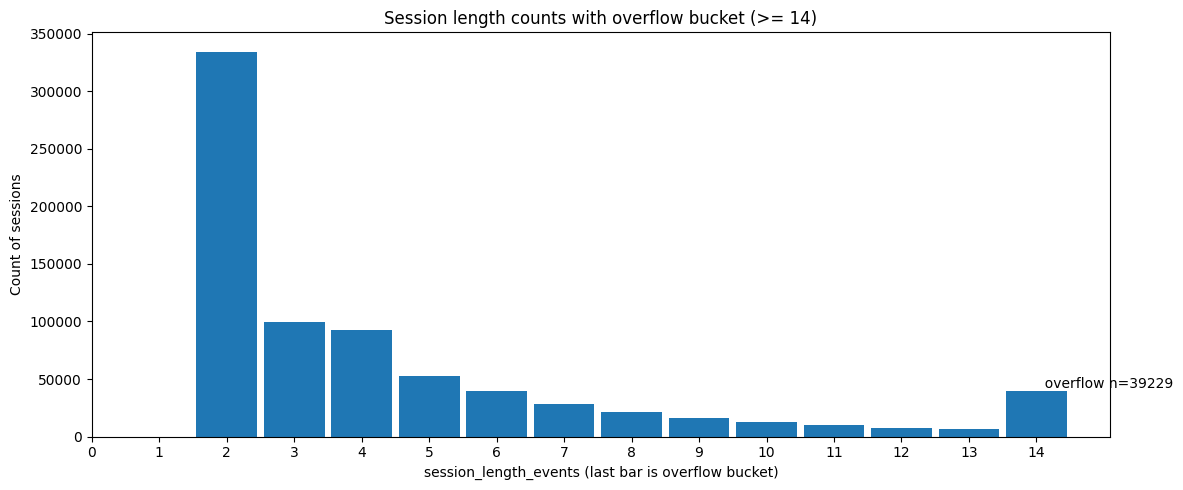

In [65]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

if "session_labeled_df" not in globals():
    raise ValueError("`session_labeled_df` not found. Run Cell 10 first.")

if "user_session_id" not in session_labeled_df.columns:
    raise ValueError("`user_session_id` not found in `session_labeled_df`.")

# Detect which timestamp column exists
if "ratingCreatedAt_ts" in session_labeled_df.columns:
    time_col = "ratingCreatedAt_ts"
elif "ratingCreatedAt" in session_labeled_df.columns:
    time_col = "ratingCreatedAt"
else:
    time_col = None

# -------- Session-level table --------
session_events_df = session_labeled_df.filter(pl.col("user_session_id").is_not_null())

session_level_df = (
    session_events_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.len().alias("session_length_events"),
        pl.col("log_delta_seconds").mean().alias("avg_log_delta_seconds_in_session"),
        pl.col("log_delta_seconds").median().alias("median_log_delta_seconds_in_session"),
        *( [
            pl.col(time_col).min().alias("session_start_ts"),
            pl.col(time_col).max().alias("session_end_ts"),
            (
                (pl.col(time_col).max().cast(pl.Int64) - pl.col(time_col).min().cast(pl.Int64))
                / 1_000_000
            ).alias("session_duration_seconds"),
        ] if time_col is not None else [] )
    )
    .sort(["raterParticipantId", "user_session_id"])
)

# -------- User-level summary --------
user_level_df = (
    session_labeled_df
    .group_by("raterParticipantId")
    .agg(
        pl.len().alias("n_total_events"),
        pl.col("in_session").sum().alias("n_in_session_events"),
        pl.col("user_session_id").drop_nulls().n_unique().alias("n_sessions"),
    )
    .with_columns(
        (pl.col("n_in_session_events") / pl.col("n_total_events")).alias("share_events_in_session"),
        pl.when(pl.col("n_sessions") > 0)
        .then(pl.col("n_in_session_events") / pl.col("n_sessions"))
        .otherwise(None)
        .alias("avg_session_length_events_per_user"),
    )
    .sort("n_sessions", descending=True)
)

# Enrich users with mean session length from session-level table
user_session_length_df = (
    session_level_df
    .group_by("raterParticipantId")
    .agg(
        pl.col("session_length_events").mean().alias("mean_session_length_events"),
        pl.col("session_length_events").median().alias("median_session_length_events"),
    )
)

user_level_df = user_level_df.join(user_session_length_df, on="raterParticipantId", how="left")

# -------- Headline metrics --------
n_users = user_level_df.height
n_users_with_sessions = user_level_df.filter(pl.col("n_sessions") > 0).height
total_sessions = session_level_df.height
n_singleton_sessions = session_level_df.filter(pl.col("session_length_events") == 1).height
share_singleton_sessions = (n_singleton_sessions / total_sessions) if total_sessions else 0.0
avg_sessions_per_user = user_level_df.select(pl.col("n_sessions").mean()).item()
median_sessions_per_user = user_level_df.select(pl.col("n_sessions").median()).item()
avg_session_length = session_level_df.select(pl.col("session_length_events").mean()).item() if total_sessions else None
median_session_length = session_level_df.select(pl.col("session_length_events").median()).item() if total_sessions else None

summary_metrics_df = pl.DataFrame(
    {
        "metric": [
            "n_users",
            "n_users_with_sessions",
            "share_users_with_sessions",
            "total_sessions",
            "n_singleton_sessions",
            "share_singleton_sessions",
            "avg_sessions_per_user",
            "median_sessions_per_user",
            "avg_session_length_events",
            "median_session_length_events",
        ],
        "value": [
            float(n_users),
            float(n_users_with_sessions),
            (n_users_with_sessions / n_users) if n_users else 0.0,
            float(total_sessions),
            float(n_singleton_sessions),
            float(share_singleton_sessions),
            float(avg_sessions_per_user) if avg_sessions_per_user is not None else 0.0,
            float(median_sessions_per_user) if median_sessions_per_user is not None else 0.0,
            float(avg_session_length) if avg_session_length is not None else 0.0,
            float(median_session_length) if median_session_length is not None else 0.0,
        ],
    }
)

print("Headline metrics:")
display(summary_metrics_df)

# -------- Graphs (log1p-transformed to reduce tail dominance) --------
sessions_per_user = user_level_df["n_sessions"].to_numpy()
session_lengths = session_level_df["session_length_events"].to_numpy() if total_sessions else np.array([])
mean_session_len_per_user = (
    user_level_df
    .select(pl.col("mean_session_length_events").drop_nulls())
    .to_series()
    .to_numpy()
)

log_sessions_per_user = np.log1p(sessions_per_user)
log_session_lengths = np.log1p(session_lengths) if len(session_lengths) > 0 else np.array([])
log_mean_session_len_per_user = np.log1p(mean_session_len_per_user) if len(mean_session_len_per_user) > 0 else np.array([])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(log_sessions_per_user, bins=50)
axes[0].set_title("log1p(Sessions per user)")
axes[0].set_xlabel("log1p(n_sessions)")
axes[0].set_ylabel("Count of users")

if len(log_session_lengths) > 0:
    axes[1].hist(log_session_lengths, bins=60)
else:
    axes[1].text(0.5, 0.5, "No sessions found", ha="center", va="center")
axes[1].set_title("log1p(Session length in events)")
axes[1].set_xlabel("log1p(session_length_events)")
axes[1].set_ylabel("Count of sessions")

if len(log_mean_session_len_per_user) > 0:
    axes[2].hist(log_mean_session_len_per_user, bins=50)
else:
    axes[2].text(0.5, 0.5, "No users with sessions", ha="center", va="center")
axes[2].set_title("log1p(Mean session length per user)")
axes[2].set_xlabel("log1p(mean_session_length_events)")
axes[2].set_ylabel("Count of users")

plt.tight_layout()
plt.show()

# -------- Additional clearer session-length count view --------
# Bucket very large session lengths into an overflow bucket so counts are easier to read.
if len(session_lengths) > 0:
    overflow_threshold = int(np.quantile(session_lengths, 0.95))
    overflow_threshold = max(overflow_threshold, 1)

    length_count_plot_df = (
        pl.DataFrame({"session_length_events": session_lengths})
        .with_columns(
            pl.when(pl.col("session_length_events") >= overflow_threshold)
            .then(pl.lit(overflow_threshold))
            .otherwise(pl.col("session_length_events"))
            .alias("length_bucket")
        )
        .group_by("length_bucket")
        .agg(pl.len().alias("n_sessions"))
        .sort("length_bucket")
    )

    x_vals = length_count_plot_df["length_bucket"].to_numpy()
    y_vals = length_count_plot_df["n_sessions"].to_numpy()
    overflow_n = int((session_lengths >= overflow_threshold).sum())

    plt.figure(figsize=(12, 5))
    plt.bar(x_vals, y_vals, width=0.9)
    plt.title(f"Session length counts with overflow bucket (>= {overflow_threshold})")
    plt.xlabel("session_length_events (last bar is overflow bucket)")
    plt.ylabel("Count of sessions")

    tick_step = max(1, int(overflow_threshold / 20))
    plt.xticks(np.arange(0, overflow_threshold + 1, tick_step))

    if overflow_n > 0:
        plt.text(
            overflow_threshold,
            y_vals[-1],
            f"  overflow n={overflow_n}",
            va="bottom",
            ha="left",
        )

    plt.tight_layout()
    plt.show()

Dirichlet interest summary:


metric,value
str,f64
"""n_sessions""",759000.0
"""n_sessions_with_interest""",695087.0
"""prop_sessions_with_interest""",0.915793
"""overall_prop_interest_ratings""",0.639172
"""avg_prop_interest_ratings_per_…",0.780556
"""median_prop_interest_ratings_p…",1.0
"""avg_interest_ratings_per_sessi…",3.093105
"""avg_ratings_per_session""",4.839241



Session-level interest quantiles:


p10,p25,p50,p75,p90
f64,f64,f64,f64,f64
0.25,0.6,1.0,1.0,1.0


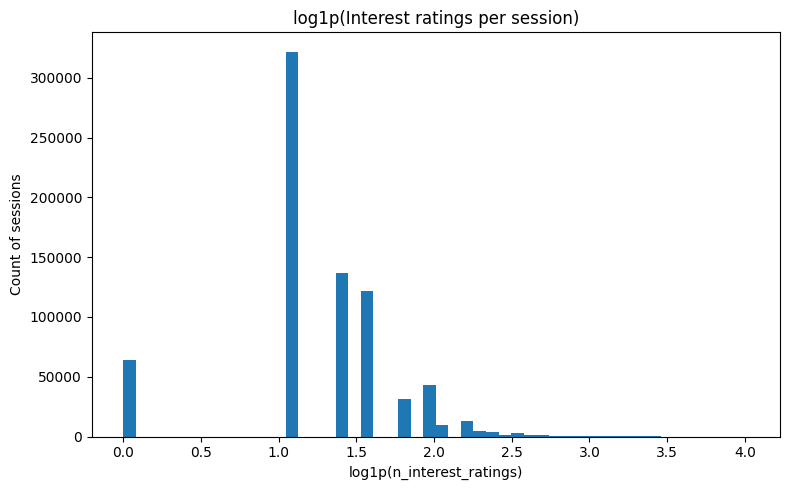


Preview of dirichlet_labeled_df:


noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,user_session_id,c_post,posterior_mean,interest
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i8,i32,u32,f64,i8
2016534713742061788,2016246745739546987,"""00002C7FD6E0080A69D0AB879C3D9B…","""FD7979DE7F187DC14A4FDF8F557242…","""2026-01-27T20:27:38.894""","""2026-01-28T15:31:55.816""","""2026-01-28T20:47:22.321""","""HELPFUL""",false,2026-01-28 20:47:22.321,null,null,0,null,null,null,0
2017641230612451495,2017578816177111423,"""00002C7FD6E0080A69D0AB879C3D9B…","""2CE75633DDBFF074EE77E7DC582D7B…","""2026-01-31T12:40:49.235""","""2026-01-31T16:48:49.996""","""2026-01-31T17:21:23.365""","""HELPFUL""",false,2026-01-31 17:21:23.365,246841,12.4165,0,null,null,null,0
2018404224149717157,2018387895459983768,"""00002C7FD6E0080A69D0AB879C3D9B…","""54F0002E8A4890D64140C45F5D108C…","""2026-02-02T18:15:48.768""","""2026-02-02T19:20:41.831""","""2026-02-02T22:44:01.605""","""HELPFUL""",false,2026-02-02 22:44:01.605,192158,12.166073,0,null,null,null,0
2012648760455671942,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""B5A7C39C8965D9D8AF5CC38B994AAC…","""2026-01-17T18:02:30.876""","""2026-01-17T22:10:32.357""","""2026-01-18T15:41:27.835""","""NOT_HELPFUL""",false,2026-01-18 15:41:27.835,null,null,0,null,null,null,0
2012693431319990371,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""D174DF64F45A03029780F273B4335C…","""2026-01-17T18:02:30.876""","""2026-01-18T01:08:02.720""","""2026-01-18T15:44:04.360""","""HELPFUL""",false,2026-01-18 15:44:04.360,156,5.049856,0,null,null,null,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2015301912090878088,2015189340234645945,"""00003D7D222733AE9D37A25B930204…","""55AC18E8A73A60B03F155142ADCD2F…","""2026-01-24T22:25:53.776""","""2026-01-25T05:53:12.999""","""2026-01-25T21:56:38.660""","""HELPFUL""",false,2026-01-25 21:56:38.660,829,6.72022,0,null,null,null,0
2015570829703102599,2015464613547049370,"""00003D7D222733AE9D37A25B930204…",null,"""2026-01-25T16:39:44.048""",null,"""2026-01-26T00:10:07.710""","""NOT_HELPFUL""",false,2026-01-26 00:10:07.710,8009,8.988321,1,2,2,0.428571,1
2015577316534149474,2015464613547049370,"""00003D7D222733AE9D37A25B930204…","""225DB19C585AACCA62007BABB6E590…","""2026-01-25T16:39:44.048""","""2026-01-26T00:07:34.534""","""2026-01-26T00:10:13.253""","""HELPFUL""",false,2026-01-26 00:10:13.253,5,1.609438,1,2,2,0.428571,1


In [66]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

if "session_labeled_df" not in globals():
    raise ValueError("`session_labeled_df` not found. Run Cell 10 first.")

required_cols = ["raterParticipantId", "user_session_id", "ratedOnTweetId", "in_session"]
missing_cols = [c for c in required_cols if c not in session_labeled_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

alpha = 1.0

# Use only rows that are in a valid session for posterior calculation
session_rows_df = session_labeled_df.filter(pl.col("user_session_id").is_not_null())

# c_post: per user-session-post rating counts
post_counts_df = (
    session_rows_df
    .group_by(["raterParticipantId", "user_session_id", "ratedOnTweetId"])
.agg(
        pl.len().alias("c_post")
    )
)

# Session totals needed for Dirichlet posterior mean
session_totals_df = (
    post_counts_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.col("c_post").sum().alias("c_session"),
        pl.len().alias("k_posts"),
    )
)

# Posterior mean under symmetric Dirichlet(alpha=1)
post_posterior_df = (
    post_counts_df
    .join(session_totals_df, on=["raterParticipantId", "user_session_id"], how="left")
    .with_columns(
        ((pl.col("c_post") + alpha) / (pl.col("c_session") + alpha * pl.col("k_posts"))).alias("posterior_mean")
    )
)

# MAP post(s) within session with c_post >= 2
max_count_df = (
    post_posterior_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.col("c_post").max().alias("max_c_post")
    )
)

interest_posts_df = (
    post_posterior_df
    .join(max_count_df, on=["raterParticipantId", "user_session_id"], how="left")
    .filter(
        (pl.col("c_post") == pl.col("max_c_post"))
        & (pl.col("c_post") >= 2)
    )
    .select([
        "raterParticipantId",
        "user_session_id",
        "ratedOnTweetId",
        "c_post",
        "posterior_mean",
    ])
    .with_columns(pl.lit(1).cast(pl.Int8).alias("interest"))
)

# Attach posterior/count info and binary interest label back to row-level data
dirichlet_labeled_df = (
    session_labeled_df
    .join(
        post_posterior_df.select([
            "raterParticipantId",
            "user_session_id",
            "ratedOnTweetId",
            "c_post",
            "posterior_mean",
        ]),
        on=["raterParticipantId", "user_session_id", "ratedOnTweetId"],
        how="left",
    )
    .join(
        interest_posts_df.select(["raterParticipantId", "user_session_id", "ratedOnTweetId", "interest"]),
        on=["raterParticipantId", "user_session_id", "ratedOnTweetId"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("user_session_id").is_null())
        .then(0)
        .otherwise(pl.col("interest").fill_null(0))
        .cast(pl.Int8)
        .alias("interest")
    )
)

# Session-level stats for interest
session_interest_df = (
    dirichlet_labeled_df
    .filter(pl.col("user_session_id").is_not_null())
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.len().alias("n_ratings_in_session"),
        pl.col("interest").sum().alias("n_interest_ratings"),
    )
    .with_columns(
        (pl.col("n_interest_ratings") > 0).cast(pl.Int8).alias("session_has_interest"),
        (pl.col("n_interest_ratings") / pl.col("n_ratings_in_session")).alias("prop_interest_ratings"),
    )
)

n_sessions = session_interest_df.height
n_sessions_with_interest = session_interest_df.filter(pl.col("session_has_interest") == 1).height
prop_sessions_with_interest = (n_sessions_with_interest / n_sessions) if n_sessions else 0.0

overall_prop_interest_ratings = (
    dirichlet_labeled_df
    .filter(pl.col("user_session_id").is_not_null())
    .select(pl.col("interest").mean())
    .item()
    if n_sessions else 0.0
)

avg_prop_interest_ratings_per_session = session_interest_df.select(pl.col("prop_interest_ratings").mean()).item() if n_sessions else 0.0
median_prop_interest_ratings_per_session = session_interest_df.select(pl.col("prop_interest_ratings").median()).item() if n_sessions else 0.0
avg_interest_ratings_per_session = session_interest_df.select(pl.col("n_interest_ratings").mean()).item() if n_sessions else 0.0
avg_ratings_per_session = session_interest_df.select(pl.col("n_ratings_in_session").mean()).item() if n_sessions else 0.0

summary_interest_df = pl.DataFrame(
    {
        "metric": [
            "n_sessions",
            "n_sessions_with_interest",
            "prop_sessions_with_interest",
            "overall_prop_interest_ratings",
            "avg_prop_interest_ratings_per_session",
            "median_prop_interest_ratings_per_session",
            "avg_interest_ratings_per_session",
            "avg_ratings_per_session",
        ],
        "value": [
            float(n_sessions),
            float(n_sessions_with_interest),
            float(prop_sessions_with_interest),
            float(overall_prop_interest_ratings) if overall_prop_interest_ratings is not None else 0.0,
            float(avg_prop_interest_ratings_per_session) if avg_prop_interest_ratings_per_session is not None else 0.0,
            float(median_prop_interest_ratings_per_session) if median_prop_interest_ratings_per_session is not None else 0.0,
            float(avg_interest_ratings_per_session) if avg_interest_ratings_per_session is not None else 0.0,
            float(avg_ratings_per_session) if avg_ratings_per_session is not None else 0.0,
        ],
    }
)

print("Dirichlet interest summary:")
display(summary_interest_df)

print("\nSession-level interest quantiles:")
display(
    session_interest_df.select(
        pl.col("prop_interest_ratings").quantile(0.10).alias("p10"),
        pl.col("prop_interest_ratings").quantile(0.25).alias("p25"),
        pl.col("prop_interest_ratings").quantile(0.50).alias("p50"),
        pl.col("prop_interest_ratings").quantile(0.75).alias("p75"),
        pl.col("prop_interest_ratings").quantile(0.90).alias("p90"),
    )
)

# Graph: logged interest ratings per session
interest_counts = session_interest_df["n_interest_ratings"].to_numpy() if n_sessions else np.array([])
log_interest_counts = np.log1p(interest_counts) if len(interest_counts) > 0 else np.array([])

plt.figure(figsize=(8, 5))
if len(log_interest_counts) > 0:
    plt.hist(log_interest_counts, bins=50)
else:
    plt.text(0.5, 0.5, "No sessions found", ha="center", va="center")
plt.title("log1p(Interest ratings per session)")
plt.xlabel("log1p(n_interest_ratings)")
plt.ylabel("Count of sessions")
plt.tight_layout()
plt.show()

print("\nPreview of dirichlet_labeled_df:")
display(
    dirichlet_labeled_df.head(20)
)

Note-level raw delta summary:


total_ratings,total_notes,n_valid_note_deltas,avg_note_delta_seconds_overall,median_note_delta_seconds_overall
u32,u32,u32,f64,f64
6499635,114204,6385431,4468.590132,168.0



Note-size / within-note activity summary:


metric,value
str,f64
"""n_notes""",114204.0
"""n_notes_with_2plus_ratings""",86239.0
"""share_notes_with_2plus_ratings""",0.755131
"""avg_ratings_per_note""",56.912499
"""median_ratings_per_note""",10.0
"""p90_ratings_per_note""",134.0
"""p99_ratings_per_note""",724.0
"""avg_of_note_avg_delta_seconds""",53040.09528
"""median_of_note_avg_delta_secon…",5236.5



Preview of note_delta_df:


noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,note_delta_seconds
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i64,i64
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…","""2021-02-04T10:08:21.128""","""2021-02-04T11:46:40.544""","""2026-02-01T14:36:13.314""","""NOT_HELPFUL""",false,2026-02-01 14:36:13.314,8,2.079442,1,null
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…","""2021-02-04T10:08:21.128""","""2021-02-04T12:00:19.835""","""2026-02-01T14:36:04.345""","""NOT_HELPFUL""",false,2026-02-01 14:36:04.345,13,2.564949,1,null
1358604958673719296,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T00:51:34.502""","""NOT_HELPFUL""",false,2026-02-09 00:51:34.502,16,2.772589,1,null
1358604958673719296,1358464064322691078,"""456D1C422BA1A09690B986C8A1DBE7…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T08:56:34.712""","""NOT_HELPFUL""",false,2026-02-09 08:56:34.712,57818,10.965055,1,29100
1358844963216326659,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""605A405C64CC57A943D086CC80E5AC…","""2021-02-07T17:14:06.633""","""2021-02-08T18:27:40.007""","""2026-02-09T00:51:18.076""","""NOT_HELPFUL""",false,2026-02-09 00:51:18.076,440090,12.994735,1,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
1421569650165370880,1421312166108581888,"""8635467C3284D81295EC243FE63D29…","""1BA344256D72112A8E254FADEF6963…","""2021-07-31T03:30:01.760""","""2021-07-31T20:33:10.744""","""2026-02-12T18:29:50.130""","""NOT_HELPFUL""",false,2026-02-12 18:29:50.130,316750,12.665868,0,null
1431744557738307588,1431669119208787974,"""F3EDDB1F065C028AF36DC098E5E1E7…","""2456B75D435E00EF7BF22530EFD2BD…","""2021-08-28T17:24:51.802""","""2021-08-28T22:24:37.754""","""2026-01-23T10:33:54.154""","""HELPFUL""",false,2026-01-23 10:33:54.154,27,3.295837,1,null
1431744557738307588,1431669119208787974,"""3AE03ADF4923AF6EA8E362C93173F5…","""2456B75D435E00EF7BF22530EFD2BD…","""2021-08-28T17:24:51.802""","""2021-08-28T22:24:37.754""","""2026-01-23T12:54:56.264""","""HELPFUL""",false,2026-01-23 12:54:56.264,28,3.332205,1,8462



Top 20 notes by number of ratings:


noteId,n_ratings_in_note,n_valid_deltas_in_note,avg_note_delta_seconds_in_note,median_note_delta_seconds_in_note
i64,u32,u32,f64,f64
2015141921954410626,8798,8797,168.446402,6.0
2016333600476528703,7225,7224,226.375,5.0
2012570670131995062,7030,7029,356.701522,4.0
2015520722970415150,6198,6197,198.126997,6.0
2015108784646152231,5799,5798,217.74474,4.0
…,…,…,…,…
2015102499670139185,4422,4421,334.30717,6.0
2014963647265611862,4298,4297,428.357924,6.0
2013693269079961830,4248,4247,420.333647,18.0


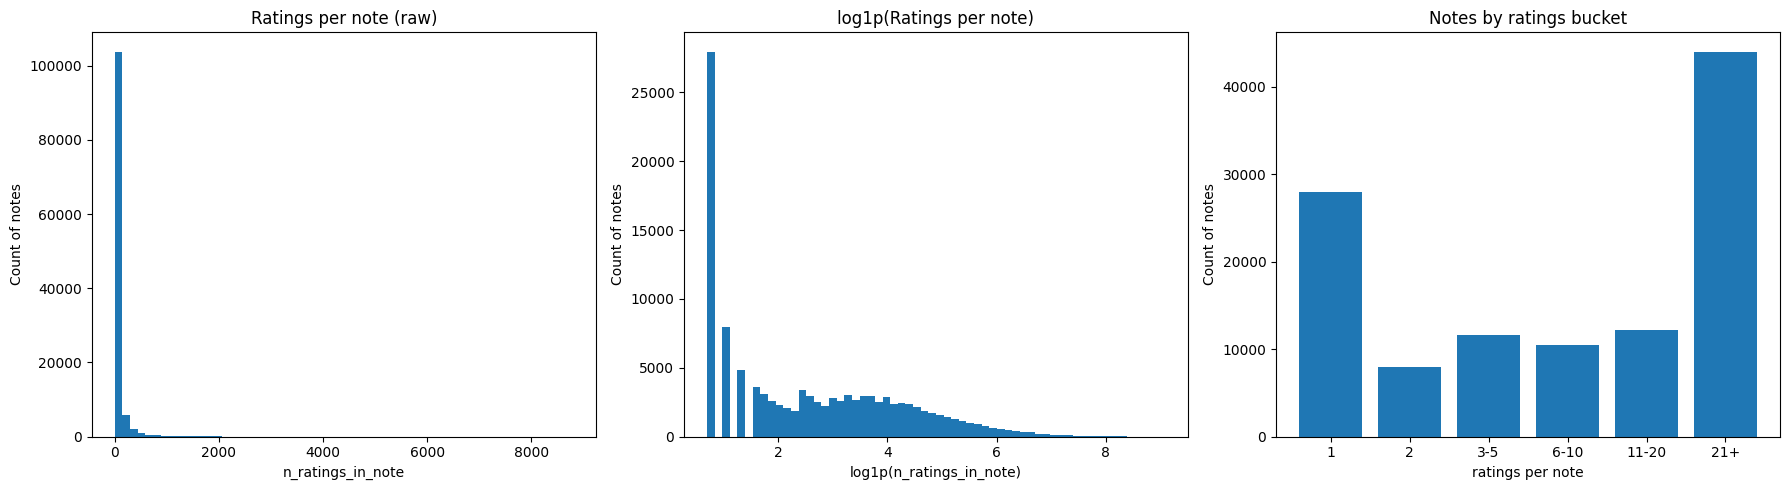

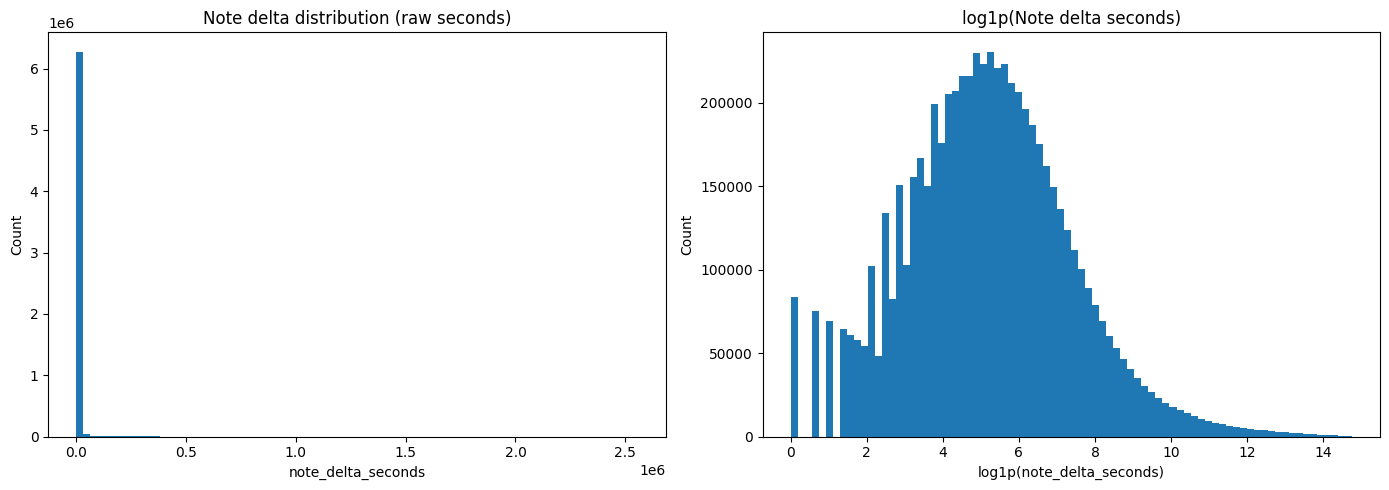

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

notes_preprocessed_df = (
    ratings_session_df
    .with_columns(
        pl.col("ratingCreatedAt")
        .cast(pl.Datetime, strict=False)
        .alias("ratingCreatedAt_ts")
    )
    .sort(["noteId", "ratingCreatedAt_ts"])
)

note_delta_df = (
    notes_preprocessed_df
    .with_columns(
        pl.col("ratingCreatedAt_ts")
        .diff()
        .over("noteId")
        .dt.total_seconds()
        .alias("note_delta_seconds")
    )
    .with_columns(
        pl.when(pl.col("note_delta_seconds").is_not_null())
        .then((pl.col("note_delta_seconds") + 1).log())
        .otherwise(None)
        .alias("log_note_delta_seconds")
    )
)

ratings_per_note_df = (
    note_delta_df
    .group_by("noteId")
    .agg(
        pl.len().alias("n_ratings_in_note"),
        pl.col("note_delta_seconds").drop_nulls().len().alias("n_valid_deltas_in_note"),
        pl.col("note_delta_seconds").mean().alias("avg_note_delta_seconds_in_note"),
        pl.col("note_delta_seconds").median().alias("median_note_delta_seconds_in_note"),
    )
)

n_notes = ratings_per_note_df.height
n_notes_multi_rating = ratings_per_note_df.filter(pl.col("n_ratings_in_note") >= 2).height
share_notes_multi_rating = (n_notes_multi_rating / n_notes) if n_notes else 0.0

note_delta_summary_df = note_delta_df.select(
    pl.len().alias("total_ratings"),
    pl.col("noteId").n_unique().alias("total_notes"),
    pl.col("note_delta_seconds").drop_nulls().len().alias("n_valid_note_deltas"),
    pl.col("note_delta_seconds").mean().alias("avg_note_delta_seconds_overall"),
    pl.col("note_delta_seconds").median().alias("median_note_delta_seconds_overall"),
)

note_size_summary_df = pl.DataFrame(
    {
        "metric": [
            "n_notes",
            "n_notes_with_2plus_ratings",
            "share_notes_with_2plus_ratings",
            "avg_ratings_per_note",
            "median_ratings_per_note",
            "p90_ratings_per_note",
            "p99_ratings_per_note",
            "avg_of_note_avg_delta_seconds",
            "median_of_note_avg_delta_seconds",
        ],
        "value": [
            float(n_notes),
            float(n_notes_multi_rating),
            float(share_notes_multi_rating),
            float(ratings_per_note_df.select(pl.col("n_ratings_in_note").mean()).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("n_ratings_in_note").median()).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("n_ratings_in_note").quantile(0.90)).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("n_ratings_in_note").quantile(0.99)).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("avg_note_delta_seconds_in_note").mean()).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("avg_note_delta_seconds_in_note").median()).item() or 0.0),
        ],
    }
)

print("Note-level raw delta summary:")
display(note_delta_summary_df)

print("\nNote-size / within-note activity summary:")
display(note_size_summary_df)

print("\nPreview of note_delta_df:")
display(
    note_delta_df.head(30)
)

print("\nTop 20 notes by number of ratings:")
display(
    ratings_per_note_df.sort("n_ratings_in_note", descending=True).head(20)
)

ratings_counts = ratings_per_note_df["n_ratings_in_note"].to_numpy()
delta_vals = (
    note_delta_df
    .select("note_delta_seconds")
    .drop_nulls()
    .to_series()
    .to_numpy()
)
log_delta_vals = (
    note_delta_df
    .select("log_note_delta_seconds")
    .drop_nulls()
    .to_series()
    .to_numpy()
)

if len(ratings_counts) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(ratings_counts, bins=60)
    axes[0].set_title("Ratings per note (raw)")
    axes[0].set_xlabel("n_ratings_in_note")
    axes[0].set_ylabel("Count of notes")

    log_counts = np.log1p(ratings_counts)
    axes[1].hist(log_counts, bins=60)
    axes[1].set_title("log1p(Ratings per note)")
    axes[1].set_xlabel("log1p(n_ratings_in_note)")
    axes[1].set_ylabel("Count of notes")

    bucket_df = (
        ratings_per_note_df
        .with_columns(
            pl.when(pl.col("n_ratings_in_note") == 1).then(pl.lit("1"))
            .when(pl.col("n_ratings_in_note") == 2).then(pl.lit("2"))
            .when(pl.col("n_ratings_in_note").is_between(3, 5)).then(pl.lit("3-5"))
            .when(pl.col("n_ratings_in_note").is_between(6, 10)).then(pl.lit("6-10"))
            .when(pl.col("n_ratings_in_note").is_between(11, 20)).then(pl.lit("11-20"))
            .otherwise(pl.lit("21+"))
            .alias("ratings_bucket")
        )
        .group_by("ratings_bucket")
        .agg(pl.len().alias("n_notes"))
    )

    bucket_order = ["1", "2", "3-5", "6-10", "11-20", "21+"]
    bucket_map = {
        row["ratings_bucket"]: row["n_notes"]
        for row in bucket_df.iter_rows(named=True)
    }
    bucket_vals = [bucket_map.get(b, 0) for b in bucket_order]

    axes[2].bar(bucket_order, bucket_vals)
    axes[2].set_title("Notes by ratings bucket")
    axes[2].set_xlabel("ratings per note")
    axes[2].set_ylabel("Count of notes")

    plt.tight_layout()
    plt.show()

if len(delta_vals) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(delta_vals, bins=80)
    axes[0].set_title("Note delta distribution (raw seconds)")
    axes[0].set_xlabel("note_delta_seconds")
    axes[0].set_ylabel("Count")

    axes[1].hist(log_delta_vals, bins=80)
    axes[1].set_title("log1p(Note delta seconds)")
    axes[1].set_xlabel("log_note_delta_seconds")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

Cluster centroids (original scale): 7.1, 90.9
Natural break cutoff: 49 ratings

Sparse pool    (2 to 49):  59,170 notes
Candidate pool (49+):       27,069 notes


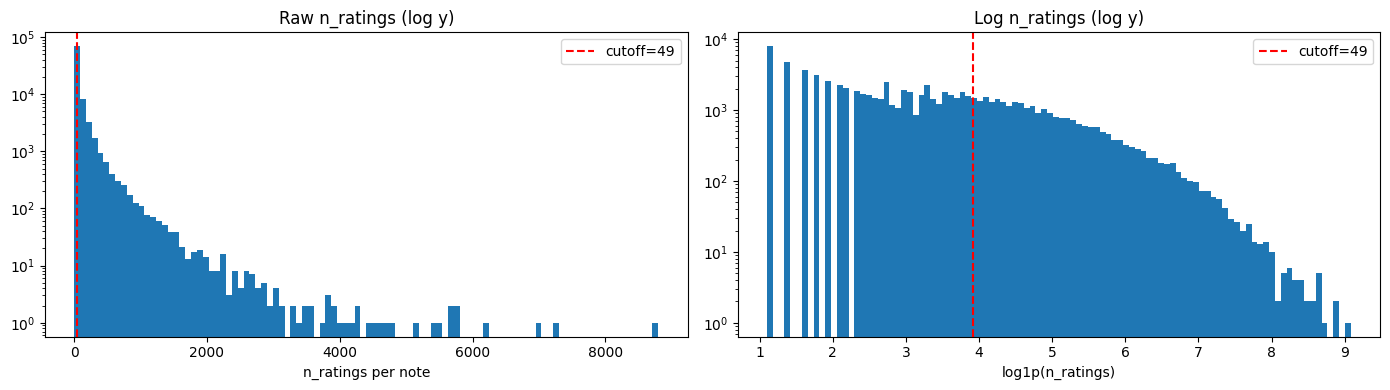

In [23]:
import numpy as np
import polars as pl
from sklearn.cluster import KMeans

# ── 1. get per-note rating counts ─────────────────────────────────────────────
note_counts = (
    ratings_session_df
    .group_by("noteId")
    .agg(pl.len().alias("n_ratings"))
    .filter(pl.col("n_ratings") > 1)  # drop singletons
)

n = note_counts["n_ratings"].to_numpy().reshape(-1, 1)
log_n = np.log1p(n)

# ── 2. jenks via 1D k-means (k=2 since you have 2 peaks) ─────────────────────
km = KMeans(n_clusters=2, random_state=42, n_init=20)
km.fit(log_n)

# cutoff = midpoint between the two centroids in original space
centroids = np.sort(np.expm1(km.cluster_centers_.flatten()))
cutoff = int(np.round(np.mean(centroids)))

print(f"Cluster centroids (original scale): {centroids[0]:.1f}, {centroids[1]:.1f}")
print(f"Natural break cutoff: {cutoff} ratings")

# ── 3. sanity check: how many notes in each cohort? ───────────────────────────
sparse    = (note_counts["n_ratings"] <= cutoff).sum()
candidate = (note_counts["n_ratings"] >  cutoff).sum()
print(f"\nSparse pool    (2 to {cutoff}):  {sparse:,} notes")
print(f"Candidate pool ({cutoff}+):       {candidate:,} notes")

# ── 4. plot to verify the break makes sense ───────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(n, bins=100, log=True)
axes[0].axvline(cutoff, color='red', linestyle='--', label=f'cutoff={cutoff}')
axes[0].set_xlabel("n_ratings per note")
axes[0].set_title("Raw n_ratings (log y)")
axes[0].legend()

axes[1].hist(log_n, bins=100, log=True)
axes[1].axvline(np.log1p(cutoff), color='red', linestyle='--', label=f'cutoff={cutoff}')
axes[1].set_xlabel("log1p(n_ratings)")
axes[1].set_title("Log n_ratings (log y)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:

note_counts_df = (
    note_delta_df
    .group_by("noteId")
    .agg(pl.len().alias("n_ratings"))
    .sort("n_ratings", descending=True)
)

print("Per-note rating counts (for Cell 16 filtering):")
display(note_counts_df.head(20))

Per-note rating counts (for Cell 16 filtering):


noteId,n_ratings
i64,u32
2015141921954410626,8798
2016333600476528703,7225
2012570670131995062,7030
2015520722970415150,6198
2015108784646152231,5799
…,…
2015102499670139185,4422
2014963647265611862,4298
2013693269079961830,4248


In [25]:
# Stratify notes by total rating count (from note_counts_df)
forgotten_notes_df = note_counts_df.filter(pl.col("n_ratings") == 1)
sparse_notes_df = note_counts_df.filter(pl.col("n_ratings").is_between(2, 4))
candidate_notes_df = note_counts_df.filter(pl.col("n_ratings") >= 5)

# Note ID lists for applying to row-level note_delta_df
forgotten_note_ids = forgotten_notes_df["noteId"].to_list()
sparse_note_ids = sparse_notes_df["noteId"].to_list()
candidate_note_ids = candidate_notes_df["noteId"].to_list()

# Row-level datasets from note_delta_df using those note sets
forgotten_df = note_delta_df.filter(pl.col("noteId").is_in(forgotten_note_ids))
sparse_df = note_delta_df.filter(pl.col("noteId").is_in(sparse_note_ids))
candidate_df = note_delta_df.filter(pl.col("noteId").is_in(candidate_note_ids))

print("Note-count category sizes (number of notes):")
display(
    pl.DataFrame({
        "category": ["forgotten (1)", "sparse (2-20)", "candidate (21+)"],
        "n_notes": [forgotten_notes_df.height, sparse_notes_df.height, candidate_notes_df.height],
        "n_rows_in_note_delta_df": [forgotten_df.height, sparse_df.height, candidate_df.height],
    })
)
forgotten_df

Note-count category sizes (number of notes):


category,n_notes,n_rows_in_note_delta_df
str,i64,i64
"""forgotten (1)""",27965,27965
"""sparse (2-20)""",16460,45017
"""candidate (21+)""",69779,6426653


noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,note_delta_seconds
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i64,i64
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…","""2021-02-04T10:08:21.128""","""2021-02-04T11:46:40.544""","""2026-02-01T14:36:13.314""","""NOT_HELPFUL""",false,2026-02-01 14:36:13.314,8,2.079442,1,null
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…","""2021-02-04T10:08:21.128""","""2021-02-04T12:00:19.835""","""2026-02-01T14:36:04.345""","""NOT_HELPFUL""",false,2026-02-01 14:36:04.345,13,2.564949,1,null
1365312734712238082,1362774562769879044,"""B19EC3432CD4CFEC68CA1C301B34E4…","""E9FA3618E5EF5961394CD4D435DC2E…","""2021-02-19T14:42:29.548""","""2021-02-26T14:48:16.897""","""2026-02-13T20:06:42.891""","""NOT_HELPFUL""",false,2026-02-13 20:06:42.891,5,1.609438,1,null
1368576992971534343,1362774562769879044,"""B19EC3432CD4CFEC68CA1C301B34E4…","""54AE76555042121BFD0A9800E502E2…","""2021-02-19T14:42:29.548""","""2021-03-07T14:59:16.711""","""2026-02-13T20:06:36.933""","""NOT_HELPFUL""",false,2026-02-13 20:06:36.933,5956,8.692154,1,null
1383882709454315528,842392085168824320,"""9A2D57C249B9C52F5F90481C006538…","""9FAA243AA35F6C4BE161A682DA5E29…","""2017-03-16T15:08:18.649""","""2021-04-18T20:38:43.888""","""2026-02-10T21:45:29.217""","""HELPFUL""",false,2026-02-10 21:45:29.217,41,3.713572,1,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023244265745175011,2023097795809362050,"""138A5CC86C485C6A9D3CDB8B03E265…","""0FF5650CCAE81A89BD976B9EABF265…","""2026-02-15T18:11:16.517""","""2026-02-16T03:53:17.671""","""2026-02-16T03:54:46.500""","""HELPFUL""",false,2026-02-16 03:54:46.500,570098,13.253564,0,null
2023244399657030064,2023157422366560260,"""673F3E152DF25D2A24EDBB7867FAA8…","""F75B04680623CD9A452496D4AB69A2…","""2026-02-15T22:08:12.596""","""2026-02-16T03:55:26.102""","""2026-02-16T03:59:53.712""","""HELPFUL""",false,2026-02-16 03:59:53.712,155,5.043425,0,null
2023244425455976896,2022740887026180430,"""EB2176A2C2250A3F25AF44B60B3126…","""D6451D0AA39C4C7700371748147442…","""2026-02-14T18:33:02.832""","""2026-02-16T03:53:55.749""","""2026-02-16T03:59:58.682""","""NOT_HELPFUL""",false,2026-02-16 03:59:58.682,434536,12.982034,0,null


Total gaps for fitting: 6,273,248

GMM fit:
  burst component   — mean: 4.149 (62.4s)  std: 1.587  weight: 0.539
  organic component — mean: 6.477 (649.1s)  std: 1.960  weight: 0.461

  decision boundary: log_delta=5.662  (286.7s)

Swarm score distribution:
  p50: 0.5976
  p75: 0.7834
  p90: 0.8656
  p95: 0.8932
  p99: 0.9132
  % > 0.5 (raw boundary): 59.8%

Raw swarm label rate: 59.8%


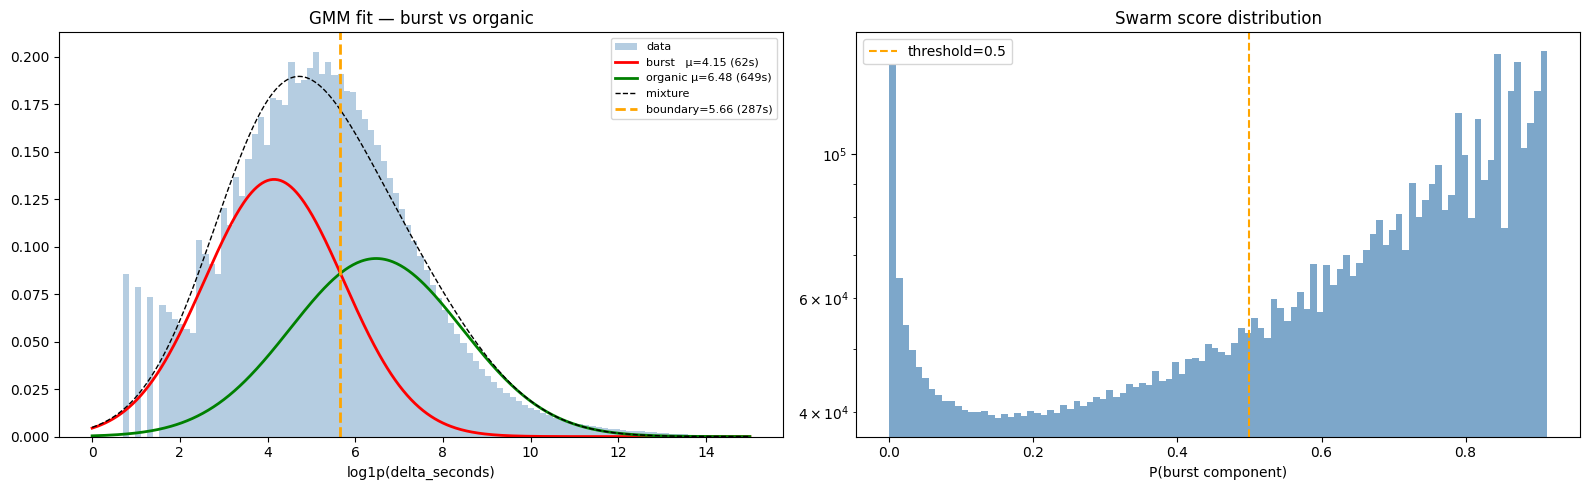

noteId,ratingCreatedAt,note_delta_seconds,log_delta,swarm_score,swarm_label_raw
i64,str,i64,f64,f64,i8
1362395868754833412,"""2026-01-21T23:30:28.321""",7348,8.90232,0.033902,0
1362395868754833412,"""2026-01-22T00:42:18.769""",4310,8.368925,0.062978,0
1362395868754833412,"""2026-01-22T02:16:36.900""",5658,8.641002,0.04624,0
1362395868754833412,"""2026-01-22T04:34:41.328""",8284,9.022202,0.029278,0
1362395868754833412,"""2026-01-22T07:43:59.378""",11358,9.337766,0.019664,0
…,…,…,…,…,…
1431744557738307588,"""2026-01-24T16:50:03.141""",739,6.60665,0.303905,0
1431744557738307588,"""2026-01-24T17:04:09.308""",846,6.741701,0.277444,0
1431744557738307588,"""2026-01-24T17:05:26.632""",77,4.356709,0.719988,1


In [35]:
import numpy as np
import polars as pl
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# ── 1. extract log deltas from candidate notes ────────────────────────────────
log_delta_arr = (
    candidate_df
    .filter(pl.col("note_delta_seconds").is_not_null())
    .filter(pl.col("note_delta_seconds") > 0)
    ["note_delta_seconds"]
    .to_numpy()
)
log_delta_arr = np.log1p(log_delta_arr).reshape(-1, 1)

print(f"Total gaps for fitting: {len(log_delta_arr):,}")

# ── 2. fit 2-component GMM ────────────────────────────────────────────────────
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    n_init=10,
    random_state=42,
)
gmm.fit(log_delta_arr)

# ensure component 0 = burst (lower mean), component 1 = organic (higher mean)
order = np.argsort(gmm.means_.flatten())
means      = gmm.means_.flatten()[order]
stds       = np.sqrt(gmm.covariances_.flatten()[order])
weights    = gmm.weights_[order]

print(f"\nGMM fit:")
print(f"  burst component   — mean: {means[0]:.3f} ({np.expm1(means[0]):.1f}s)  std: {stds[0]:.3f}  weight: {weights[0]:.3f}")
print(f"  organic component — mean: {means[1]:.3f} ({np.expm1(means[1]):.1f}s)  std: {stds[1]:.3f}  weight: {weights[1]:.3f}")

# ── 3. decision boundary (where burst and organic densities are equal) ────────
from scipy.stats import norm
from scipy.optimize import brentq

def density_diff(x):
    d_burst   = weights[0] * norm.pdf(x, means[0], stds[0])
    d_organic = weights[1] * norm.pdf(x, means[1], stds[1])
    return d_burst - d_organic

# find crossover between the two means
boundary_log = brentq(density_diff, means[0], means[1])
boundary_s   = np.expm1(boundary_log)
print(f"\n  decision boundary: log_delta={boundary_log:.3f}  ({boundary_s:.1f}s)")

# ── 4. per-rating swarm score = P(burst component | log_delta) ───────────────
# refit with ordered labels baked in via a wrapper
# sklearn predict_proba returns P(component k | x) directly
# we need to map back to burst=0 after ordering

# reorder internal gmm params to match our burst=0 convention
gmm_means_ordered      = gmm.means_[order]
gmm_precisions_ordered = gmm.precisions_cholesky_[order]
gmm_weights_ordered    = gmm.weights_[order]

# score all candidate log-deltas
swarm_scores = gmm.predict_proba(log_delta_arr)[:, order[0]]  # P(burst)

print(f"\nSwarm score distribution:")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(swarm_scores, p):.4f}")
print(f"  % > 0.5 (raw boundary): {(swarm_scores > 0.5).mean()*100:.1f}%")

# ── 5. attach scores back to candidate_df ────────────────────────────────────
scored_df = (
    candidate_df
    .filter(pl.col("note_delta_seconds").is_not_null())
    .filter(pl.col("note_delta_seconds") > 0)
    .with_columns(
        pl.Series("log_delta",   log_delta_arr.flatten()),
        pl.Series("swarm_score", swarm_scores),
        (pl.Series("swarm_score", swarm_scores) > 0.5)
            .cast(pl.Int8)
            .alias("swarm_label_raw"),
    )
)

print(f"\nRaw swarm label rate: {scored_df['swarm_label_raw'].mean()*100:.1f}%")

# ── 6. plot ───────────────────────────────────────────────────────────────────
x_plot = np.linspace(0, 15, 500)
d_burst   = weights[0] * norm.pdf(x_plot, means[0], stds[0])
d_organic = weights[1] * norm.pdf(x_plot, means[1], stds[1])
d_total   = d_burst + d_organic

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: fitted components over histogram
axes[0].hist(log_delta_arr, bins=100, density=True, alpha=0.4, color="steelblue", label="data")
axes[0].plot(x_plot, d_burst,   color="red",   linewidth=2, label=f"burst   μ={means[0]:.2f} ({np.expm1(means[0]):.0f}s)")
axes[0].plot(x_plot, d_organic, color="green", linewidth=2, label=f"organic μ={means[1]:.2f} ({np.expm1(means[1]):.0f}s)")
axes[0].plot(x_plot, d_total,   color="black", linewidth=1, linestyle="--", label="mixture")
axes[0].axvline(boundary_log, color="orange", linewidth=2, linestyle="--", label=f"boundary={boundary_log:.2f} ({boundary_s:.0f}s)")
axes[0].set_xlabel("log1p(delta_seconds)")
axes[0].set_title("GMM fit — burst vs organic")
axes[0].legend(fontsize=8)

# right: swarm score distribution
axes[1].hist(swarm_scores, bins=100, log=True, color="steelblue", alpha=0.7)
axes[1].axvline(0.5, color="orange", linestyle="--", label="threshold=0.5")
axes[1].set_xlabel("P(burst component)")
axes[1].set_title("Swarm score distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

display(scored_df.select([
    "noteId", "ratingCreatedAt", "note_delta_seconds",
    "log_delta", "swarm_score", "swarm_label_raw"
]).head(20))

Notes with baseline: 69,779
Global fallback — mean: 5.502  std: 1.913

Label breakdown:
  coordinated (<=7s): 517,648  (8.1%)
  burst (z>1.0):       857,940  (13.5%)
  organic:            4,981,286  (78.4%)
  total swarm:        1,375,588  (21.6%)

Note-level summary:
  notes with any swarm:        67,544
  notes with swarm_rate > 0.5: 86
  median swarm_rate:           0.167


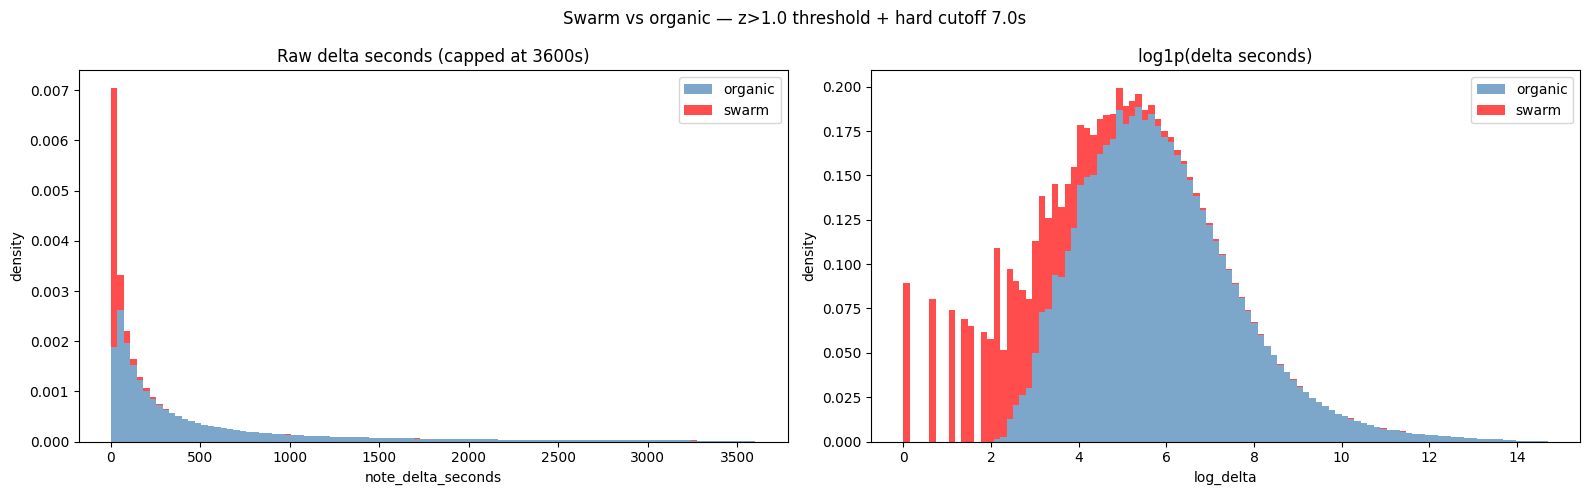

noteId,n_gaps,n_swarm,swarm_rate,max_swarm_score,n_coordinated,n_burst
i64,u32,i64,f64,f64,u32,u32
2015487955633426573,776,753,0.970361,1.0,753,0
2019216683785986383,676,629,0.930473,1.0,629,0
2015108843135783264,515,459,0.891262,1.0,459,0
2019235499509182574,767,664,0.865711,1.0,664,0
2015497096615374922,1372,1178,0.858601,1.0,1137,41
…,…,…,…,…,…,…
2014012972897607973,91,61,0.67033,1.0,55,6
2012570670131995062,7029,4640,0.660122,1.0,4316,324
2015489740590760245,596,389,0.652685,1.0,321,68


In [47]:
import numpy as np
import polars as pl
from scipy.special import expit

HARD_CUTOFF_S = 7.0

# ── 1. compute note baseline excluding sub-7s ─────────────────────────────────
global_std = float(
    candidate_df
    .filter(pl.col("note_delta_seconds") > HARD_CUTOFF_S)
    ["note_delta_seconds"]
    .log1p()
    .std()
)
global_mean = float(
    candidate_df
    .filter(pl.col("note_delta_seconds") > HARD_CUTOFF_S)
    ["note_delta_seconds"]
    .log1p()
    .mean()
)

note_baseline_df = (
    candidate_df
    .filter(pl.col("note_delta_seconds").is_not_null())
    .filter(pl.col("note_delta_seconds") > HARD_CUTOFF_S)
    .with_columns(pl.col("note_delta_seconds").log1p().alias("log_delta"))
    .group_by("noteId")
    .agg([
        pl.col("log_delta").mean().alias("note_mean_log_delta"),
        pl.col("log_delta").std().alias("note_std_log_delta"),
        pl.col("log_delta").count().alias("n_organic_gaps"),
    ])
)

# fix nulls in Python where we have full control
note_baseline = {}
for row in note_baseline_df.iter_rows(named=True):
    mean = row["note_mean_log_delta"]
    std  = row["note_std_log_delta"]
    note_baseline[row["noteId"]] = (
        mean if mean is not None else global_mean,
        std  if (std is not None and std > 0) else global_std,
    )

print(f"Notes with baseline: {len(note_baseline):,}")
print(f"Global fallback — mean: {global_mean:.3f}  std: {global_std:.3f}")

# ── 2. score all gaps ─────────────────────────────────────────────────────────
rows = (
    candidate_df
    .filter(pl.col("note_delta_seconds").is_not_null())
    .filter(pl.col("note_delta_seconds") >= 0)
    .sort(["noteId", "ratingCreatedAt"])
    .to_dicts()
)

note_mean_arr = np.array([
    note_baseline.get(r["noteId"], (global_mean, global_std))[0]
    for r in rows
], dtype=np.float64)

note_std_arr = np.array([
    note_baseline.get(r["noteId"], (global_mean, global_std))[1]
    for r in rows
], dtype=np.float64)

gap_arr       = np.array([r["note_delta_seconds"] for r in rows], dtype=np.float64)
log_delta_arr = np.log1p(gap_arr)

z_arr         = (note_mean_arr - log_delta_arr) / note_std_arr  # positive = faster than baseline

# ── 3. hybrid labeling ────────────────────────────────────────────────────────
is_coordinated = gap_arr <= HARD_CUTOFF_S

# z > 1 threshold: gap must be >1 std dev faster than note baseline
Z_THRESHOLD = 1.0
swarm_label  = np.where(
    is_coordinated,
    1,
    (z_arr > Z_THRESHOLD).astype(np.int8)
).astype(np.int8)

# smooth score: sigmoid shifted so z=Z_THRESHOLD maps to 0.5
swarm_score  = np.where(
    is_coordinated,
    1.0,
    expit(z_arr - Z_THRESHOLD)
)

swarm_type   = np.where(
    is_coordinated, "coordinated",
    np.where(swarm_label == 1, "burst", "organic")
)

# ── 4. build output df ────────────────────────────────────────────────────────
scored_df = pl.DataFrame({
    "noteId":              [r["noteId"]           for r in rows],
    "ratingCreatedAt":     [r["ratingCreatedAt"]  for r in rows],
    "note_delta_seconds":  gap_arr.tolist(),
    "log_delta":           log_delta_arr.tolist(),
    "note_mean_log_delta": note_mean_arr.tolist(),
    "note_std_log_delta":  note_std_arr.tolist(),
    "z_score":             z_arr.tolist(),
    "swarm_score":         swarm_score.tolist(),
    "swarm_label":         swarm_label.tolist(),
    "swarm_type":          swarm_type.tolist(),
})

# ── 5. summary ────────────────────────────────────────────────────────────────
print(f"\nLabel breakdown:")
print(f"  coordinated (<=7s): {is_coordinated.sum():,}  "
      f"({is_coordinated.mean()*100:.1f}%)")
print(f"  burst (z>{Z_THRESHOLD}):       "
      f"{((~is_coordinated) & (swarm_label==1)).sum():,}  "
      f"({((~is_coordinated) & (swarm_label==1)).mean()*100:.1f}%)")
print(f"  organic:            {(swarm_label==0).sum():,}  "
      f"({(swarm_label==0).mean()*100:.1f}%)")
print(f"  total swarm:        {swarm_label.sum():,}  "
      f"({swarm_label.mean()*100:.1f}%)")

# ── 6. note-level summary ─────────────────────────────────────────────────────
note_summary_df = (
    scored_df
    .group_by("noteId")
    .agg([
        pl.len().alias("n_gaps"),
        pl.col("swarm_label").sum().alias("n_swarm"),
        pl.col("swarm_label").mean().alias("swarm_rate"),
        pl.col("swarm_score").max().alias("max_swarm_score"),
        (pl.col("swarm_type") == "coordinated").sum().alias("n_coordinated"),
        (pl.col("swarm_type") == "burst").sum().alias("n_burst"),
    ])
    .sort("swarm_rate", descending=True)
)

print(f"\nNote-level summary:")
print(f"  notes with any swarm:        "
      f"{(note_summary_df['n_swarm'] > 0).sum():,}")
print(f"  notes with swarm_rate > 0.5: "
      f"{(note_summary_df['swarm_rate'] > 0.5).sum():,}")
print(f"  median swarm_rate:           "
      f"{note_summary_df['swarm_rate'].median():.3f}")

# ── 7. stacked histogram ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title, xlim in zip(
    axes,
    ["note_delta_seconds", "log_delta"],
    ["Raw delta seconds (capped at 3600s)", "log1p(delta seconds)"],
    [3600, None],
):
    organic = scored_df.filter(pl.col("swarm_label") == 0)[col].to_numpy()
    swarm   = scored_df.filter(pl.col("swarm_label") == 1)[col].to_numpy()

    if xlim:
        organic = organic[organic <= xlim]
        swarm   = swarm[swarm <= xlim]

    ax.hist([organic, swarm], bins=100, stacked=True,
            color=["steelblue", "red"],
            label=["organic", "swarm"],
            density=True, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.legend()

plt.suptitle(f"Swarm vs organic — z>{Z_THRESHOLD} threshold + hard cutoff {HARD_CUTOFF_S}s")
plt.tight_layout()
plt.show()

display(note_summary_df.head(20))

Z-threshold → gap time mapping:
  z>0.5 → gaps < 93s  (33.8% of gaps flagged)
  z>1.0 → gaps < 35s  (16.6% of gaps flagged)
  z>1.5 → gaps < 13s  (4.0% of gaps flagged)
  z>2.0 → gaps < 4s  (0.0% of gaps flagged)
  z>2.5 → gaps < 1s  (0.0% of gaps flagged)
  z>3.0 → gaps < -0s  (0.0% of gaps flagged)


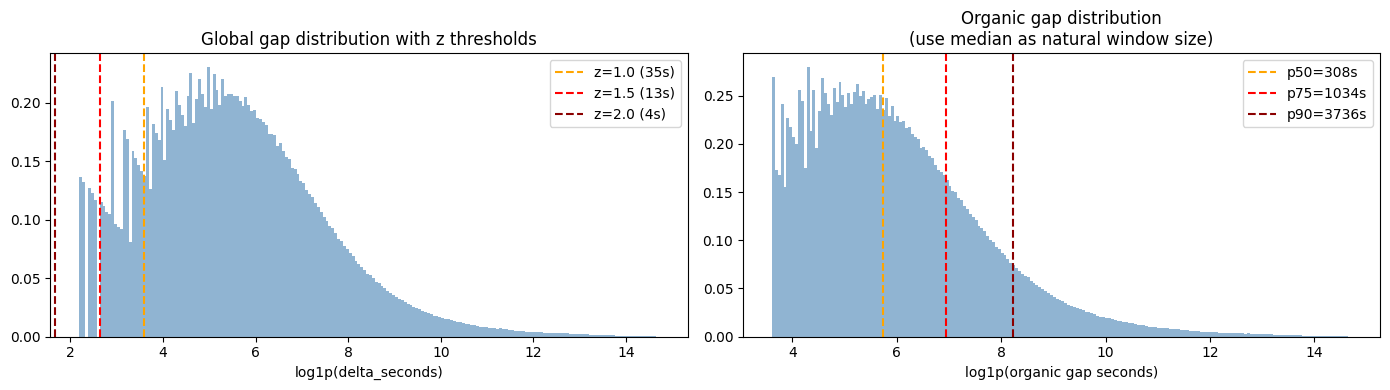


Organic gap percentiles (natural window candidates):
  p25: 112s  (0.03h)
  p50: 308s  (0.09h)
  p75: 1034s  (0.29h)
  p90: 3736s  (1.04h)


In [48]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# get all gaps above hard cutoff
gaps = (
    candidate_df
    .filter(pl.col("note_delta_seconds") > 7)
    .filter(pl.col("note_delta_seconds").is_not_null())
    ["note_delta_seconds"]
    .to_numpy()
)
log_gaps = np.log1p(gaps)

global_mean = log_gaps.mean()
global_std  = log_gaps.std()
z_gaps      = (global_mean - log_gaps) / global_std  # positive = faster

# ── what z-threshold corresponds to what gap time? ───────────────────────────
print("Z-threshold → gap time mapping:")
for z in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    gap_s = np.expm1(global_mean - z * global_std)
    pct   = (z_gaps > z).mean() * 100
    print(f"  z>{z:.1f} → gaps < {gap_s:.0f}s  ({pct:.1f}% of gaps flagged)")

# ── what does the gap time distribution look like at the fast tail? ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(log_gaps, bins=200, density=True, alpha=0.6, color="steelblue")
for z, col in [(1.0, "orange"), (1.5, "red"), (2.0, "darkred")]:
    boundary = global_mean - z * global_std
    axes[0].axvline(boundary, color=col, linestyle="--", 
                    label=f"z={z} ({np.expm1(boundary):.0f}s)")
axes[0].set_xlabel("log1p(delta_seconds)")
axes[0].set_title("Global gap distribution with z thresholds")
axes[0].legend()

# ── window: look at inter-burst gap distribution ──────────────────────────────
# natural window = typical gap between burst episodes
# proxy: distribution of gaps that are NOT burst (z < 1)
organic_gaps = gaps[z_gaps < 1.0]
axes[1].hist(np.log1p(organic_gaps), bins=200, 
             density=True, alpha=0.6, color="steelblue")
axes[1].set_xlabel("log1p(organic gap seconds)")
axes[1].set_title("Organic gap distribution\n(use median as natural window size)")

for p, col in [(50, "orange"), (75, "red"), (90, "darkred")]:
    v = np.percentile(organic_gaps, p)
    axes[1].axvline(np.log1p(v), color=col, linestyle="--",
                    label=f"p{p}={v:.0f}s")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nOrganic gap percentiles (natural window candidates):")
for p in [25, 50, 75, 90]:
    print(f"  p{p}: {np.percentile(organic_gaps, p):.0f}s  "
          f"({np.percentile(organic_gaps, p)/3600:.2f}h)")

In [68]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — swarm scoring + episode detection + onset fix
# output keeps ALL rows/cols from base note_delta_df
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
import polars as pl
from scipy.special import expit

# ── empirically derived parameters ───────────────────────────────────────────
HARD_CUTOFF_S    = 7.0
Z_THRESHOLD      = 1.5
EPISODE_WINDOW_S = 1034.0

# ── 1. base df (keep everything) + scoring subset ─────────────────────────────
base_df = (
    note_delta_df
    .with_row_index("base_row_idx")
    .with_columns(
        pl.col("ratingCreatedAt")
        .cast(pl.Datetime, strict=False)
        .alias("ratingCreatedAt_ts")
    )
    .sort(["noteId", "ratingCreatedAt_ts"])
)

eligible_df = (
    base_df
    .filter(pl.col("note_delta_seconds").is_not_null())
    .filter(pl.col("note_delta_seconds") >= 0)
)

print(f"Base rows (all notes):      {base_df.height:,}")
print(f"Rows used for scoring only: {eligible_df.height:,}")
print(f"Total notes in base:        {base_df['noteId'].n_unique():,}")

if eligible_df.height == 0:
    raise ValueError("No non-null note_delta_seconds rows found for scoring.")

# ── 2. global baseline from eligible gaps above hard cutoff ───────────────────
baseline_df = eligible_df.filter(pl.col("note_delta_seconds") > HARD_CUTOFF_S)
if baseline_df.height == 0:
    baseline_df = eligible_df

log_organic = np.log1p(
    baseline_df["note_delta_seconds"].to_numpy().astype(np.float64)
)
global_mean = float(log_organic.mean())
global_std  = float(log_organic.std()) if float(log_organic.std()) > 0 else 1.0

print(f"\nGlobal baseline:")
print(f"  mean log_delta : {global_mean:.3f}  ({np.expm1(global_mean):.0f}s)")
print(f"  std  log_delta : {global_std:.3f}")
print(f"  z>{Z_THRESHOLD} boundary : {np.expm1(global_mean - Z_THRESHOLD * global_std):.0f}s")

# ── 3. compute per-rating scores on eligible rows ─────────────────────────────
rows = eligible_df.select([
    "base_row_idx", "noteId", "ratingCreatedAt_ts", "note_delta_seconds"
]).to_dicts()

base_row_idx_arr = np.array([r["base_row_idx"] for r in rows], dtype=np.int64)
note_ids         = [r["noteId"] for r in rows]
timestamps       = [r["ratingCreatedAt_ts"] for r in rows]
gap_arr          = np.array([r["note_delta_seconds"] for r in rows], dtype=np.float64)

log_delta = np.log1p(gap_arr)
z_arr     = (global_mean - log_delta) / global_std

is_coordinated = gap_arr <= HARD_CUTOFF_S
is_burst       = (~is_coordinated) & (z_arr > Z_THRESHOLD)
swarm_score    = np.where(is_coordinated, 1.0, expit(z_arr - Z_THRESHOLD))

# ── 4. episode detection ──────────────────────────────────────────────────────
is_swarm_candidate = is_coordinated | is_burst
episode_id_arr     = np.full(len(rows), -1, dtype=np.int32)
ep_counter         = 0

note_indices = {}
for i, note_id in enumerate(note_ids):
    note_indices.setdefault(note_id, []).append(i)

for note_id, indices in note_indices.items():
    in_episode = False
    current_ep = -1
    last_burst_ts = None

    for i in indices:
        ts = timestamps[i]
        is_sc = bool(is_swarm_candidate[i])

        if is_sc:
            if not in_episode:
                current_ep  = ep_counter
                ep_counter += 1
                in_episode  = True
            else:
                if last_burst_ts is not None:
                    try:
                        delta = (ts - last_burst_ts).total_seconds()
                    except (AttributeError, TypeError):
                        delta = float(ts - last_burst_ts) / 1e9
                    if delta > EPISODE_WINDOW_S:
                        current_ep  = ep_counter
                        ep_counter += 1

            episode_id_arr[i] = current_ep
            last_burst_ts = ts
        else:
            if in_episode and last_burst_ts is not None:
                try:
                    delta = (ts - last_burst_ts).total_seconds()
                except (AttributeError, TypeError):
                    delta = float(ts - last_burst_ts) / 1e9
                if delta > EPISODE_WINDOW_S:
                    in_episode = False
                    last_burst_ts = None

# ── 5. burst onset fix ────────────────────────────────────────────────────────
swarm_label_arr = (is_coordinated | is_burst).astype(np.int8)
swarm_type_arr = np.where(
    is_coordinated, "coordinated",
    np.where(is_burst, "burst", "organic")
).tolist()
swarm_score_arr = swarm_score.copy()

for note_id, indices in note_indices.items():
    indices = sorted(indices)
    ep_ids  = episode_id_arr[indices]

    for pos, i in enumerate(indices):
        if ep_ids[pos] >= 0:
            is_episode_onset = (pos == 0) or (ep_ids[pos - 1] != ep_ids[pos])
            if is_episode_onset and pos > 0:
                prev_i = indices[pos - 1]
                if episode_id_arr[prev_i] == -1:
                    episode_id_arr[prev_i]  = ep_ids[pos]
                    swarm_label_arr[prev_i] = 1
                    swarm_type_arr[prev_i]  = "burst_onset"
                    swarm_score_arr[prev_i] = swarm_score_arr[i]

# ── 6. join labels back onto full base df ─────────────────────────────────────
labels_df = pl.DataFrame({
    "base_row_idx": base_row_idx_arr.tolist(),
    "log_delta": log_delta.tolist(),
    "z_score": z_arr.tolist(),
    "swarm_score": swarm_score_arr.tolist(),
    "swarm_label": swarm_label_arr.tolist(),
    "swarm_type": swarm_type_arr,
    "episode_id": episode_id_arr.tolist(),
})

scored_df = (
    base_df
    .join(labels_df, on="base_row_idx", how="left")
    .with_columns([
        pl.col("swarm_label").fill_null(0).cast(pl.Int8),
        pl.col("swarm_type").fill_null("organic"),
        pl.col("episode_id").fill_null(-1).cast(pl.Int32),
    ])
    .drop("base_row_idx")
)

# ── 7. episode-level summary ──────────────────────────────────────────────────
episode_df = (
    scored_df
    .filter(pl.col("episode_id") >= 0)
    .group_by(["noteId", "episode_id"])
    .agg([
        pl.len().alias("episode_n_ratings"),
        pl.col("ratingCreatedAt_ts").min().alias("episode_start"),
        pl.col("ratingCreatedAt_ts").max().alias("episode_end"),
        pl.col("swarm_score").mean().alias("episode_mean_score"),
        (pl.col("swarm_type") == "coordinated").sum().alias("n_coordinated"),
        (pl.col("swarm_type") == "burst").sum().alias("n_burst"),
        (pl.col("swarm_type") == "burst_onset").sum().alias("n_onset"),
    ])
    .sort(["noteId", "episode_start"])
)

# ── 8. note-level summary ─────────────────────────────────────────────────────
note_summary_df = (
    scored_df
    .group_by("noteId")
    .agg([
        pl.len().alias("n_total_ratings"),
        pl.col("swarm_label").sum().alias("n_swarm"),
        pl.col("swarm_label").mean().alias("swarm_rate"),
        pl.col("swarm_score").max().alias("max_swarm_score"),
        (pl.col("swarm_type") == "coordinated").sum().alias("n_coordinated"),
        (pl.col("swarm_type") == "burst").sum().alias("n_burst"),
        (pl.col("swarm_type") == "burst_onset").sum().alias("n_onset"),
        (pl.col("episode_id") >= 0).sum().alias("n_episode_ratings"),
        pl.col("episode_id").filter(pl.col("episode_id") >= 0).n_unique().alias("n_episodes"),
    ])
    .with_columns(
        (pl.col("n_episode_ratings") / pl.col("n_total_ratings")).alias("episode_concentration")
    )
    .sort("swarm_rate", descending=True)
)

# ── 9. print summary ──────────────────────────────────────────────────────────
print(f"\nLabel breakdown (full base df):")
for t in ["coordinated", "burst", "burst_onset", "organic"]:
    n = (scored_df["swarm_type"] == t).sum()
    pct = n / scored_df.height * 100
    print(f"  {t:20s}: {n:,}  ({pct:.1f}%)")

total_swarm = int(scored_df["swarm_label"].sum())
print(f"  {'total swarm':20s}: {total_swarm:,}  ({total_swarm / scored_df.height * 100:.1f}%)")
print(f"\nEpisodes detected    : {ep_counter:,}")
print(f"Notes with episodes  : {(note_summary_df['n_episodes'] > 0).sum():,}")
print(f"Median episodes/note : {note_summary_df['n_episodes'].median():.1f}")
print(f"Median swarm_rate    : {note_summary_df['swarm_rate'].median():.3f}")

display(note_summary_df.head(20))
display(episode_df.head(20))
display(scored_df.select([
    "noteId", "ratingCreatedAt", "ratingCreatedAt_ts",
    "note_delta_seconds", "log_delta", "z_score", "swarm_score",
    "swarm_label", "swarm_type", "episode_id",
]).head(30))

Base rows (all notes):      6,499,635
Rows used for scoring only: 6,385,431
Total notes in base:        114,204

Global baseline:
  mean log_delta : 5.523  (249s)
  std  log_delta : 1.940
  z>1.5 boundary : 13s

Label breakdown (full base df):
  coordinated         : 517,736  (8.0%)
  burst               : 231,714  (3.6%)
  burst_onset         : 458,418  (7.1%)
  organic             : 5,291,767  (81.4%)
  total swarm         : 1,207,868  (18.6%)

Episodes detected    : 133,623
Notes with episodes  : 31,454
Median episodes/note : 0.0
Median swarm_rate    : 0.000


noteId,n_total_ratings,n_swarm,swarm_rate,max_swarm_score,n_coordinated,n_burst,n_onset,n_episode_ratings,n_episodes,episode_concentration
i64,u32,i64,f64,f64,u32,u32,u32,u32,u32,f64
2015487955633426573,777,773,0.994852,1.0,753,18,2,773,1,0.994852
2015108843135783264,516,511,0.99031,1.0,459,38,14,511,1,0.99031
2019216683785986383,677,652,0.963072,1.0,629,18,5,652,1,0.963072
2015616754001785175,63,60,0.952381,1.0,47,9,4,60,1,0.952381
2019235499509182574,768,731,0.951823,1.0,664,45,22,731,1,0.951823
…,…,…,…,…,…,…,…,…,…,…
2015848933503668492,214,194,0.906542,1.0,120,30,44,194,1,0.906542
2022034415216734621,40,36,0.9,1.0,25,5,6,36,1,0.9
2015848259604897814,9,8,0.888889,1.0,6,2,0,8,1,0.888889


noteId,episode_id,episode_n_ratings,episode_start,episode_end,episode_mean_score,n_coordinated,n_burst,n_onset
i64,i32,u32,datetime[μs],datetime[μs],f64,u32,u32,u32
1544710223100870657,0,2,2026-01-24 16:36:48.350,2026-01-24 16:37:01.046,0.506131,0,1,1
1544710223100870657,1,2,2026-01-25 10:06:40.876,2026-01-25 10:06:41.488,1.0,1,0,1
1645824012709142530,2,2,2026-02-04 20:56:41.918,2026-02-04 20:56:45.091,1.0,1,0,1
1671540126143397888,3,2,2026-01-19 20:45:39.457,2026-01-19 20:45:42.680,1.0,1,0,1
1671540126143397888,4,21,2026-01-19 21:14:44.190,2026-01-19 22:02:53.103,0.823185,7,5,9
…,…,…,…,…,…,…,…,…
1671543937289318402,15,2,2026-02-01 20:48:37.966,2026-02-01 20:48:48.797,0.527629,0,1,1
1671687655501750272,16,2,2026-01-19 21:25:18.035,2026-01-19 21:25:22.416,1.0,1,0,1
1671869172555415555,17,2,2026-01-19 22:39:09.033,2026-01-19 22:39:09.260,1.0,1,0,1


noteId,ratingCreatedAt,ratingCreatedAt_ts,note_delta_seconds,log_delta,z_score,swarm_score,swarm_label,swarm_type,episode_id
i64,str,datetime[μs],i64,f64,f64,f64,i8,str,i32
1357294499052085249,"""2026-02-01T14:36:13.314""",2026-02-01 14:36:13.314,null,null,null,null,0,"""organic""",-1
1357297935407603713,"""2026-02-01T14:36:04.345""",2026-02-01 14:36:04.345,null,null,null,null,0,"""organic""",-1
1358604958673719296,"""2026-02-09T00:51:34.502""",2026-02-09 00:51:34.502,null,null,null,null,0,"""organic""",-1
1358604958673719296,"""2026-02-09T08:56:34.712""",2026-02-09 08:56:34.712,29100,10.278528,-2.451231,0.018868,0,"""organic""",-1
1358844963216326659,"""2026-02-09T00:51:18.076""",2026-02-09 00:51:18.076,null,null,null,null,0,"""organic""",-1
…,…,…,…,…,…,…,…,…,…
1421569650165370880,"""2026-02-12T18:29:50.130""",2026-02-12 18:29:50.130,null,null,null,null,0,"""organic""",-1
1431744557738307588,"""2026-01-23T10:33:54.154""",2026-01-23 10:33:54.154,null,null,null,null,0,"""organic""",-1
1431744557738307588,"""2026-01-23T12:54:56.264""",2026-01-23 12:54:56.264,8462,9.043459,-1.814648,0.035072,0,"""organic""",-1


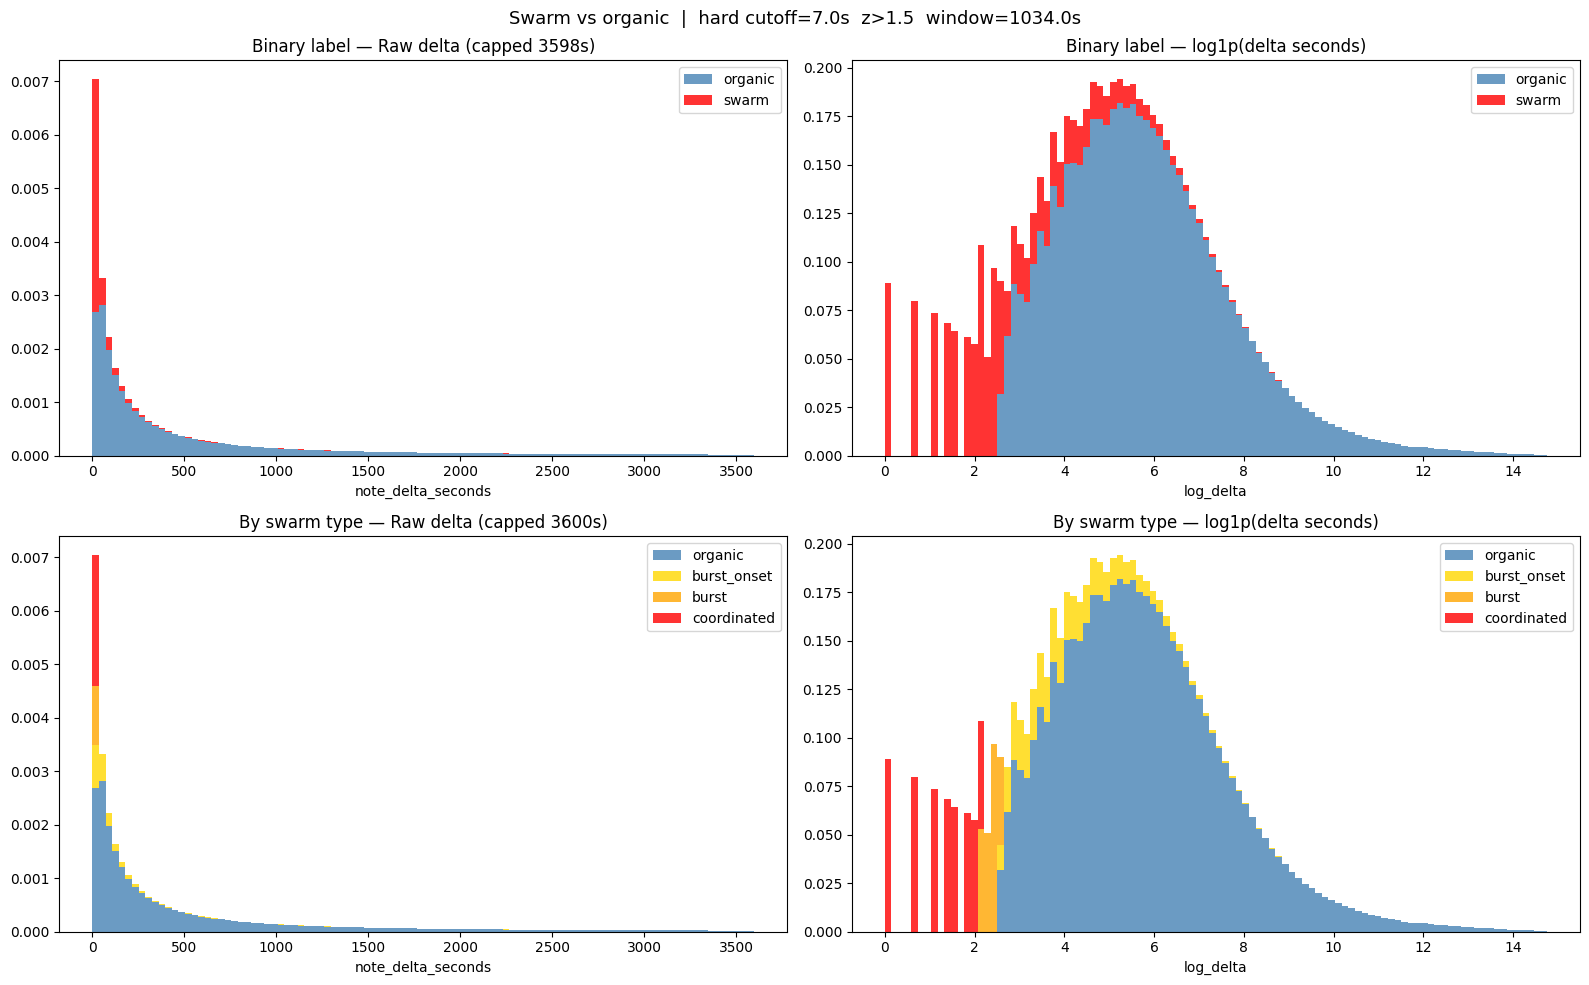

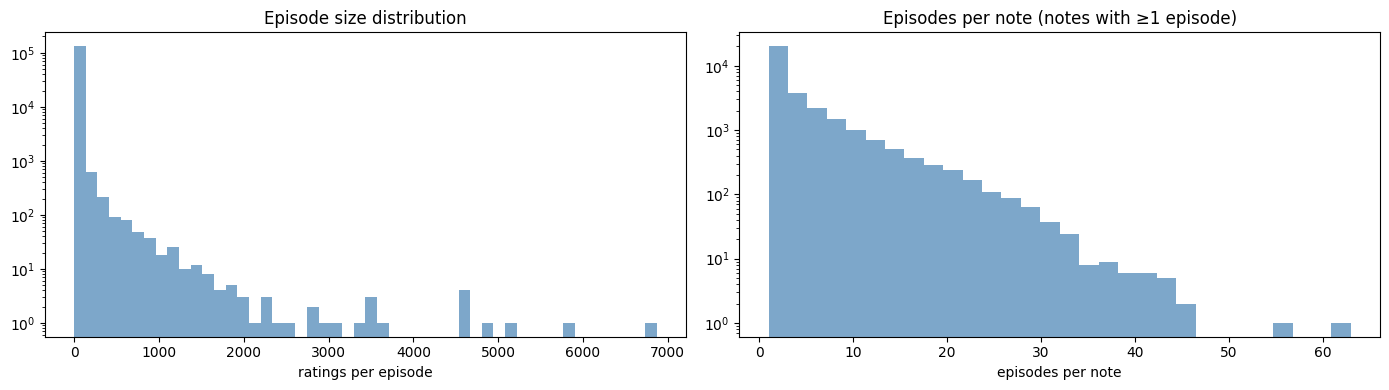

In [69]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — stacked histogram: swarm vs organic
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

type_colors = {
    "organic":     "steelblue",
    "burst_onset": "gold",
    "burst":       "orange",
    "coordinated": "red",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── top row: stacked by swarm_label (binary) ──────────────────────────────────
for ax, col, title, cap in zip(
    axes[0],
    ["note_delta_seconds", "log_delta"],
    [f"Raw delta (capped {HARD_CUTOFF_S*514:.0f}s)",
     "log1p(delta seconds)"],
    [3600, None],
):
    o = scored_df.filter(pl.col("swarm_label") == 0)[col].to_numpy()
    s = scored_df.filter(pl.col("swarm_label") == 1)[col].to_numpy()
    if cap:
        o = o[o <= cap]
        s = s[s <= cap]
    ax.hist([o, s], bins=100, stacked=True,
            color=["steelblue", "red"],
            label=["organic", "swarm"],
            density=True, alpha=0.8)
    ax.set_xlabel(col)
    ax.set_title(f"Binary label — {title}")
    ax.legend()

# ── bottom row: stacked by swarm_type (4 categories) ─────────────────────────
for ax, col, title, cap in zip(
    axes[1],
    ["note_delta_seconds", "log_delta"],
    [f"Raw delta (capped 3600s)", "log1p(delta seconds)"],
    [3600, None],
):
    arrays = []
    colors = []
    labels = []
    for t in ["organic", "burst_onset", "burst", "coordinated"]:
        arr = scored_df.filter(pl.col("swarm_type") == t)[col].to_numpy()
        if cap:
            arr = arr[arr <= cap]
        arrays.append(arr)
        colors.append(type_colors[t])
        labels.append(t)

    ax.hist(arrays, bins=100, stacked=True,
            color=colors, label=labels,
            density=True, alpha=0.8)
    ax.set_xlabel(col)
    ax.set_title(f"By swarm type — {title}")
    ax.legend()

plt.suptitle(
    f"Swarm vs organic  |  hard cutoff={HARD_CUTOFF_S}s  "
    f"z>{Z_THRESHOLD}  window={EPISODE_WINDOW_S}s",
    fontsize=13
)
plt.tight_layout()
plt.show()

# ── episode size distribution ─────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))

ep_sizes = episode_df["episode_n_ratings"].to_numpy()
axes2[0].hist(ep_sizes, bins=50, log=True, color="steelblue", alpha=0.7)
axes2[0].set_xlabel("ratings per episode")
axes2[0].set_title("Episode size distribution")

n_eps = note_summary_df["n_episodes"].to_numpy()
axes2[1].hist(n_eps[n_eps > 0], bins=30, log=True,
              color="steelblue", alpha=0.7)
axes2[1].set_xlabel("episodes per note")
axes2[1].set_title("Episodes per note (notes with ≥1 episode)")

plt.tight_layout()
plt.show()

In [70]:
scored_df.write_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\swarm_data.csv")
scored_df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,note_delta_seconds,log_delta,z_score,swarm_score,swarm_label,swarm_type,episode_id
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i64,i64,f64,f64,f64,i8,str,i32
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…","""2021-02-04T10:08:21.128""","""2021-02-04T11:46:40.544""","""2026-02-01T14:36:13.314""","""NOT_HELPFUL""",false,2026-02-01 14:36:13.314,8,2.079442,1,null,null,null,null,0,"""organic""",-1
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…","""2021-02-04T10:08:21.128""","""2021-02-04T12:00:19.835""","""2026-02-01T14:36:04.345""","""NOT_HELPFUL""",false,2026-02-01 14:36:04.345,13,2.564949,1,null,null,null,null,0,"""organic""",-1
1358604958673719296,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T00:51:34.502""","""NOT_HELPFUL""",false,2026-02-09 00:51:34.502,16,2.772589,1,null,null,null,null,0,"""organic""",-1
1358604958673719296,1358464064322691078,"""456D1C422BA1A09690B986C8A1DBE7…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T08:56:34.712""","""NOT_HELPFUL""",false,2026-02-09 08:56:34.712,57818,10.965055,1,29100,10.278528,-2.451231,0.018868,0,"""organic""",-1
1358844963216326659,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""605A405C64CC57A943D086CC80E5AC…","""2021-02-07T17:14:06.633""","""2021-02-08T18:27:40.007""","""2026-02-09T00:51:18.076""","""NOT_HELPFUL""",false,2026-02-09 00:51:18.076,440090,12.994735,1,null,null,null,null,0,"""organic""",-1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023245297170706904,2023153108512309584,"""56DAFBED112FD8D9E6A2E070001656…","""3C5A1B72768E4780AFCFA8706CCEAE…","""2026-02-15T21:51:04.093""","""2026-02-16T03:57:23.583""","""2026-02-16T04:01:22.259""","""HELPFUL""",false,2026-02-16 04:01:22.259,10860,9.292842,1,109,4.70048,0.423822,0.25423,0,"""organic""",-1
2023245297170706904,2023153108512309584,"""0CC6C916682B1F5EEB9606DC9EDC04…","""3C5A1B72768E4780AFCFA8706CCEAE…","""2026-02-15T21:51:04.093""","""2026-02-16T03:57:23.583""","""2026-02-16T04:02:11.312""","""HELPFUL""",false,2026-02-16 04:02:11.312,7381,8.906664,1,49,3.912023,0.830211,0.338544,0,"""organic""",-1
2023246107833205109,2023140091011768398,"""9D487BB7F46D89C45EB01CEE86DD01…","""321A09B1A7D9195A6DAF1CE967CCB1…","""2026-02-15T20:59:20.479""","""2026-02-16T04:00:36.859""","""2026-02-16T04:02:37.228""","""HELPFUL""",false,2026-02-16 04:02:37.228,3000,8.006368,0,null,null,null,null,0,"""organic""",-1


In [ ]:
ratings_session_df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session
i64,i64,str,str,str,str,str,str,bool,str,i64,f64,i64
2016534713742061788,2016246745739546987,"""00002C7FD6E0080A69D0AB879C3D9B…","""FD7979DE7F187DC14A4FDF8F557242…","""2026-01-27T20:27:38.894""","""2026-01-28T15:31:55.816""","""2026-01-28T20:47:22.321""","""HELPFUL""",false,"""2026-01-28T20:47:22.321000""",null,null,0
2017641230612451495,2017578816177111423,"""00002C7FD6E0080A69D0AB879C3D9B…","""2CE75633DDBFF074EE77E7DC582D7B…","""2026-01-31T12:40:49.235""","""2026-01-31T16:48:49.996""","""2026-01-31T17:21:23.365""","""HELPFUL""",false,"""2026-01-31T17:21:23.365000""",246841,12.4165,0
2018404224149717157,2018387895459983768,"""00002C7FD6E0080A69D0AB879C3D9B…","""54F0002E8A4890D64140C45F5D108C…","""2026-02-02T18:15:48.768""","""2026-02-02T19:20:41.831""","""2026-02-02T22:44:01.605""","""HELPFUL""",false,"""2026-02-02T22:44:01.605000""",192158,12.166073,0
2012648760455671942,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""B5A7C39C8965D9D8AF5CC38B994AAC…","""2026-01-17T18:02:30.876""","""2026-01-17T22:10:32.357""","""2026-01-18T15:41:27.835""","""NOT_HELPFUL""",false,"""2026-01-18T15:41:27.835000""",null,null,0
2012693431319990371,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""D174DF64F45A03029780F273B4335C…","""2026-01-17T18:02:30.876""","""2026-01-18T01:08:02.720""","""2026-01-18T15:44:04.360""","""HELPFUL""",false,"""2026-01-18T15:44:04.360000""",156,5.049856,0
…,…,…,…,…,…,…,…,…,…,…,…,…
2020752418963669036,2020604630657302841,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""BA48B1306E38D71468370309229E18…","""2026-02-08T21:04:19.624""","""2026-02-09T06:51:35.102""","""2026-02-09T08:02:06.384""","""NOT_HELPFUL""",false,"""2026-02-09T08:02:06.384000""",1041422,13.856098,0
2021916824426701208,2021784932818067904,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""E6ABEA01CD00795F7897A1245141FF…","""2026-02-12T03:14:25.588""","""2026-02-12T11:58:30.999""","""2026-02-12T15:50:43.969""","""HELPFUL""",false,"""2026-02-12T15:50:43.969000""",287317,12.568341,0
2019488960465031197,2019467286298472468,"""FFFFC46B8555A97065DB39F7D600C8…","""8D8A300EC055D96FC685C886688785…","""2026-02-05T17:44:55.598""","""2026-02-05T19:11:03.122""","""2026-02-06T08:34:11.398""","""HELPFUL""",false,"""2026-02-06T08:34:11.398000""",null,null,0


In [71]:
dirichlet_labeled_df.write_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\dirichlet.csv")
dirichlet_labeled_df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,user_session_id,c_post,posterior_mean,interest
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i8,i32,u32,f64,i8
2016534713742061788,2016246745739546987,"""00002C7FD6E0080A69D0AB879C3D9B…","""FD7979DE7F187DC14A4FDF8F557242…","""2026-01-27T20:27:38.894""","""2026-01-28T15:31:55.816""","""2026-01-28T20:47:22.321""","""HELPFUL""",false,2026-01-28 20:47:22.321,null,null,0,null,null,null,0
2017641230612451495,2017578816177111423,"""00002C7FD6E0080A69D0AB879C3D9B…","""2CE75633DDBFF074EE77E7DC582D7B…","""2026-01-31T12:40:49.235""","""2026-01-31T16:48:49.996""","""2026-01-31T17:21:23.365""","""HELPFUL""",false,2026-01-31 17:21:23.365,246841,12.4165,0,null,null,null,0
2018404224149717157,2018387895459983768,"""00002C7FD6E0080A69D0AB879C3D9B…","""54F0002E8A4890D64140C45F5D108C…","""2026-02-02T18:15:48.768""","""2026-02-02T19:20:41.831""","""2026-02-02T22:44:01.605""","""HELPFUL""",false,2026-02-02 22:44:01.605,192158,12.166073,0,null,null,null,0
2012648760455671942,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""B5A7C39C8965D9D8AF5CC38B994AAC…","""2026-01-17T18:02:30.876""","""2026-01-17T22:10:32.357""","""2026-01-18T15:41:27.835""","""NOT_HELPFUL""",false,2026-01-18 15:41:27.835,null,null,0,null,null,null,0
2012693431319990371,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""D174DF64F45A03029780F273B4335C…","""2026-01-17T18:02:30.876""","""2026-01-18T01:08:02.720""","""2026-01-18T15:44:04.360""","""HELPFUL""",false,2026-01-18 15:44:04.360,156,5.049856,0,null,null,null,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2020752418963669036,2020604630657302841,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""BA48B1306E38D71468370309229E18…","""2026-02-08T21:04:19.624""","""2026-02-09T06:51:35.102""","""2026-02-09T08:02:06.384""","""NOT_HELPFUL""",false,2026-02-09 08:02:06.384,1041422,13.856098,0,null,null,null,0
2021916824426701208,2021784932818067904,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""E6ABEA01CD00795F7897A1245141FF…","""2026-02-12T03:14:25.588""","""2026-02-12T11:58:30.999""","""2026-02-12T15:50:43.969""","""HELPFUL""",false,2026-02-12 15:50:43.969,287317,12.568341,0,null,null,null,0
2019488960465031197,2019467286298472468,"""FFFFC46B8555A97065DB39F7D600C8…","""8D8A300EC055D96FC685C886688785…","""2026-02-05T17:44:55.598""","""2026-02-05T19:11:03.122""","""2026-02-06T08:34:11.398""","""HELPFUL""",false,2026-02-06 08:34:11.398,null,null,0,null,null,null,0


In [74]:
import polars as pl
from pathlib import Path

# Validate required dataframes
required = ["scored_df", "ratings_session_df", "dirichlet_labeled_df"]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError(f"Missing required dataframes: {missing}")

def join_without_duplicate_columns(left_df: pl.DataFrame, right_df: pl.DataFrame) -> pl.DataFrame:
    preferred_keys = [
        "noteId",
        "ratingCreatedAt",
        "raterParticipantId",
        "ratedOnTweetId",
    ]
    join_keys = [k for k in preferred_keys if k in left_df.columns and k in right_df.columns]

    if not join_keys:
        raise ValueError(
            "No shared join keys found between dataframes. "
            "Expected at least one of: noteId, ratingCreatedAt, raterParticipantId, ratedOnTweetId."
        )

    right_unique_cols = [
        c for c in right_df.columns
        if c not in join_keys and c not in left_df.columns
    ]

    return left_df.join(
        right_df.select(join_keys + right_unique_cols),
        on=join_keys,
        how="left",
    )

# Join scored -> ratings_session -> dirichlet, avoiding duplicate columns
merged_df = join_without_duplicate_columns(scored_df, ratings_session_df)
merged_df = join_without_duplicate_columns(merged_df, dirichlet_labeled_df)

# Save to requested folder
out_dir = Path(r"C:\Users\wongb\user_trajectories_winter\494-user-trajectories\students\benedict\data\behavior")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "joined_scored_ratings_dirichlet.csv"

merged_df.write_csv(str(out_path))
print(f"Saved: {out_path}")
merged_df

Saved: C:\Users\wongb\user_trajectories_winter\494-user-trajectories\students\benedict\data\behavior\joined_scored_ratings_dirichlet.csv


noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,note_delta_seconds,log_delta,z_score,swarm_score,swarm_label,swarm_type,episode_id,user_session_id,c_post,posterior_mean,interest
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i64,i64,f64,f64,f64,i8,str,i32,i32,u32,f64,i8
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…","""2021-02-04T10:08:21.128""","""2021-02-04T11:46:40.544""","""2026-02-01T14:36:13.314""","""NOT_HELPFUL""",false,2026-02-01 14:36:13.314,8,2.079442,1,null,null,null,null,0,"""organic""",-1,3,4,1.0,1
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…","""2021-02-04T10:08:21.128""","""2021-02-04T12:00:19.835""","""2026-02-01T14:36:04.345""","""NOT_HELPFUL""",false,2026-02-01 14:36:04.345,13,2.564949,1,null,null,null,null,0,"""organic""",-1,3,4,1.0,1
1358604958673719296,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T00:51:34.502""","""NOT_HELPFUL""",false,2026-02-09 00:51:34.502,16,2.772589,1,null,null,null,null,0,"""organic""",-1,1,2,1.0,1
1358604958673719296,1358464064322691078,"""456D1C422BA1A09690B986C8A1DBE7…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T08:56:34.712""","""NOT_HELPFUL""",false,2026-02-09 08:56:34.712,57818,10.965055,1,29100,10.278528,-2.451231,0.018868,0,"""organic""",-1,3,2,1.0,1
1358844963216326659,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""605A405C64CC57A943D086CC80E5AC…","""2021-02-07T17:14:06.633""","""2021-02-08T18:27:40.007""","""2026-02-09T00:51:18.076""","""NOT_HELPFUL""",false,2026-02-09 00:51:18.076,440090,12.994735,1,null,null,null,null,0,"""organic""",-1,1,2,1.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023245297170706904,2023153108512309584,"""56DAFBED112FD8D9E6A2E070001656…","""3C5A1B72768E4780AFCFA8706CCEAE…","""2026-02-15T21:51:04.093""","""2026-02-16T03:57:23.583""","""2026-02-16T04:01:22.259""","""HELPFUL""",false,2026-02-16 04:01:22.259,10860,9.292842,1,109,4.70048,0.423822,0.25423,0,"""organic""",-1,6,2,1.0,1
2023245297170706904,2023153108512309584,"""0CC6C916682B1F5EEB9606DC9EDC04…","""3C5A1B72768E4780AFCFA8706CCEAE…","""2026-02-15T21:51:04.093""","""2026-02-16T03:57:23.583""","""2026-02-16T04:02:11.312""","""HELPFUL""",false,2026-02-16 04:02:11.312,7381,8.906664,1,49,3.912023,0.830211,0.338544,0,"""organic""",-1,12,2,1.0,1
2023246107833205109,2023140091011768398,"""9D487BB7F46D89C45EB01CEE86DD01…","""321A09B1A7D9195A6DAF1CE967CCB1…","""2026-02-15T20:59:20.479""","""2026-02-16T04:00:36.859""","""2026-02-16T04:02:37.228""","""HELPFUL""",false,2026-02-16 04:02:37.228,3000,8.006368,0,null,null,null,null,0,"""organic""",-1,null,null,null,0


In [75]:
master_df = pl.read_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\joined_scored_ratings_dirichlet.csv")
master_df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,note_delta_seconds,log_delta,z_score,swarm_score,swarm_label,swarm_type,episode_id,user_session_id,c_post,posterior_mean,interest
i64,i64,str,str,str,str,str,str,bool,str,i64,f64,i64,i64,f64,f64,f64,i64,str,i64,i64,i64,f64,i64
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…","""2021-02-04T10:08:21.128""","""2021-02-04T11:46:40.544""","""2026-02-01T14:36:13.314""","""NOT_HELPFUL""",false,"""2026-02-01T14:36:13.314000""",8,2.079442,1,null,null,null,null,0,"""organic""",-1,3,4,1.0,1
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…","""2021-02-04T10:08:21.128""","""2021-02-04T12:00:19.835""","""2026-02-01T14:36:04.345""","""NOT_HELPFUL""",false,"""2026-02-01T14:36:04.345000""",13,2.564949,1,null,null,null,null,0,"""organic""",-1,3,4,1.0,1
1358604958673719296,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T00:51:34.502""","""NOT_HELPFUL""",false,"""2026-02-09T00:51:34.502000""",16,2.772589,1,null,null,null,null,0,"""organic""",-1,1,2,1.0,1
1358604958673719296,1358464064322691078,"""456D1C422BA1A09690B986C8A1DBE7…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T08:56:34.712""","""NOT_HELPFUL""",false,"""2026-02-09T08:56:34.712000""",57818,10.965055,1,29100,10.278528,-2.451231,0.018868,0,"""organic""",-1,3,2,1.0,1
1358844963216326659,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""605A405C64CC57A943D086CC80E5AC…","""2021-02-07T17:14:06.633""","""2021-02-08T18:27:40.007""","""2026-02-09T00:51:18.076""","""NOT_HELPFUL""",false,"""2026-02-09T00:51:18.076000""",440090,12.994735,1,null,null,null,null,0,"""organic""",-1,1,2,1.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023245297170706904,2023153108512309584,"""56DAFBED112FD8D9E6A2E070001656…","""3C5A1B72768E4780AFCFA8706CCEAE…","""2026-02-15T21:51:04.093""","""2026-02-16T03:57:23.583""","""2026-02-16T04:01:22.259""","""HELPFUL""",false,"""2026-02-16T04:01:22.259000""",10860,9.292842,1,109,4.70048,0.423822,0.25423,0,"""organic""",-1,6,2,1.0,1
2023245297170706904,2023153108512309584,"""0CC6C916682B1F5EEB9606DC9EDC04…","""3C5A1B72768E4780AFCFA8706CCEAE…","""2026-02-15T21:51:04.093""","""2026-02-16T03:57:23.583""","""2026-02-16T04:02:11.312""","""HELPFUL""",false,"""2026-02-16T04:02:11.312000""",7381,8.906664,1,49,3.912023,0.830211,0.338544,0,"""organic""",-1,12,2,1.0,1
2023246107833205109,2023140091011768398,"""9D487BB7F46D89C45EB01CEE86DD01…","""321A09B1A7D9195A6DAF1CE967CCB1…","""2026-02-15T20:59:20.479""","""2026-02-16T04:00:36.859""","""2026-02-16T04:02:37.228""","""HELPFUL""",false,"""2026-02-16T04:02:37.228000""",3000,8.006368,0,null,null,null,null,0,"""organic""",-1,null,null,null,0


Overall proportions summary:


n_ratings,prop_swarm_label,prop_in_session,prop_interest,prop_from_notification,prop_multi_true_gt1,prop_none_true,prop_all_four_true
u32,f64,f64,f64,f64,f64,f64,f64
6499635,0.185836,0.565106,0.3612,0.019807,0.404171,0.345782,0.000135



Distribution of how many types are true per rating:


n_types_true,n_ratings,prop_ratings
i8,u32,f64
0,2247455,0.345782
1,1625217,0.250047
2,2149729,0.330746
3,476356,0.07329
4,878,0.000135



Top 12 exact 4-flag combinations:


combo,n_ratings,prop_ratings
str,u32,f64
"""swarm=0 | session=0 | interest…",2247455,0.345782
"""swarm=0 | session=1 | interest…",1875372,0.288535
"""swarm=0 | session=1 | interest…",1069758,0.164587
"""swarm=1 | session=0 | interest…",483361,0.074367
"""swarm=1 | session=1 | interest…",469130,0.072178
…,…,…
"""swarm=0 | session=1 | interest…",24797,0.003815
"""swarm=1 | session=0 | interest…",23737,0.003652
"""swarm=1 | session=1 | interest…",4939,0.00076



Daily proportions preview:


day_start,n_ratings,prop_swarm_label,prop_in_session,prop_interest,prop_from_notification
datetime[μs],u32,f64,f64,f64,f64
2026-01-17 00:00:00,162042,0.149794,0.527913,0.360863,0.037786
2026-01-18 00:00:00,199501,0.147323,0.523521,0.338986,0.02396
2026-01-19 00:00:00,205590,0.15455,0.535999,0.348008,0.023265
2026-01-20 00:00:00,212670,0.161334,0.568411,0.369441,0.020323
2026-01-21 00:00:00,211886,0.179361,0.573724,0.367122,0.020431
…,…,…,…,…,…
2026-01-24 00:00:00,332685,0.388791,0.689938,0.455458,0.010031
2026-01-25 00:00:00,335352,0.260255,0.657381,0.398059,0.012384
2026-01-26 00:00:00,285370,0.239188,0.63677,0.396156,0.010912


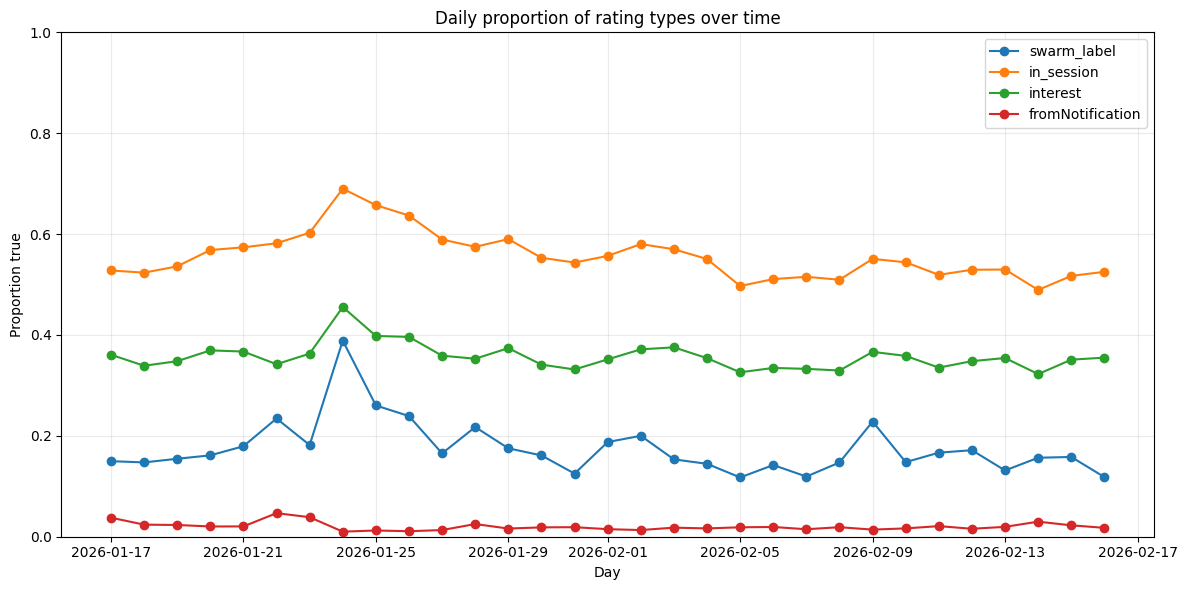

In [77]:
import polars as pl
import matplotlib.pyplot as plt

if "master_df" not in globals():
    raise ValueError("`master_df` not found. Run Cell 27 first.")

required_cols = ["swarm_label", "in_session", "interest", "fromNotification", "ratingCreatedAt"]
missing_cols = [c for c in required_cols if c not in master_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in master_df: {missing_cols}")

df_flags = (
    master_df
    .with_columns([
        pl.col("ratingCreatedAt").cast(pl.Datetime, strict=False).alias("ratingCreatedAt_ts"),
        (pl.col("swarm_label").fill_null(0).cast(pl.Int64, strict=False) > 0).cast(pl.Int8).alias("swarm_flag"),
        (pl.col("in_session").fill_null(0).cast(pl.Int64, strict=False) > 0).cast(pl.Int8).alias("in_session_flag"),
        (pl.col("interest").fill_null(0).cast(pl.Int64, strict=False) > 0).cast(pl.Int8).alias("interest_flag"),
        pl.when(
            pl.col("fromNotification")
            .cast(pl.Utf8, strict=False)
            .str.to_lowercase()
            .is_in(["true", "1", "t", "yes", "y"])
)
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .cast(pl.Int8)
        .alias("from_notification_flag"),
    ])
    .with_columns(
        (
            pl.col("swarm_flag")
            + pl.col("in_session_flag")
            + pl.col("interest_flag")
            + pl.col("from_notification_flag")
        ).alias("n_types_true")
    )
)

overall_summary_df = df_flags.select([
    pl.len().alias("n_ratings"),
    pl.col("swarm_flag").mean().alias("prop_swarm_label"),
    pl.col("in_session_flag").mean().alias("prop_in_session"),
    pl.col("interest_flag").mean().alias("prop_interest"),
    pl.col("from_notification_flag").mean().alias("prop_from_notification"),
    (pl.col("n_types_true") > 1).mean().alias("prop_multi_true_gt1"),
    (pl.col("n_types_true") == 0).mean().alias("prop_none_true"),
    (pl.col("n_types_true") == 4).mean().alias("prop_all_four_true"),
])

n_types_dist_df = (
    df_flags
    .group_by("n_types_true")
    .agg(pl.len().alias("n_ratings"))
    .sort("n_types_true")
    .with_columns((pl.col("n_ratings") / pl.col("n_ratings").sum()).alias("prop_ratings"))
)

combo_summary_df = (
    df_flags
    .with_columns(
        pl.concat_str(
            [
                pl.lit("swarm="), pl.col("swarm_flag").cast(pl.Utf8), pl.lit(" | "),
                pl.lit("session="), pl.col("in_session_flag").cast(pl.Utf8), pl.lit(" | "),
                pl.lit("interest="), pl.col("interest_flag").cast(pl.Utf8), pl.lit(" | "),
                pl.lit("notif="), pl.col("from_notification_flag").cast(pl.Utf8),
            ]
        ).alias("combo")
    )
    .group_by("combo")
    .agg(pl.len().alias("n_ratings"))
    .sort("n_ratings", descending=True)
    .with_columns((pl.col("n_ratings") / pl.col("n_ratings").sum()).alias("prop_ratings"))
)

print("Overall proportions summary:")
display(overall_summary_df)

print("\nDistribution of how many types are true per rating:")
display(n_types_dist_df)

print("\nTop 12 exact 4-flag combinations:")
display(combo_summary_df.head(12))

daily_df = (
    df_flags
    .drop_nulls(["ratingCreatedAt_ts"])
.with_columns(pl.col("ratingCreatedAt_ts").dt.truncate("1d").alias("day_start"))
    .group_by("day_start")
    .agg([
        pl.len().alias("n_ratings"),
        pl.col("swarm_flag").mean().alias("prop_swarm_label"),
        pl.col("in_session_flag").mean().alias("prop_in_session"),
        pl.col("interest_flag").mean().alias("prop_interest"),
        pl.col("from_notification_flag").mean().alias("prop_from_notification"),
    ])
    .sort("day_start")
)

print("\nDaily proportions preview:")
display(daily_df.head(12))

plot_df = daily_df.to_pandas()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["day_start"], plot_df["prop_swarm_label"], marker="o", label="swarm_label")
plt.plot(plot_df["day_start"], plot_df["prop_in_session"], marker="o", label="in_session")
plt.plot(plot_df["day_start"], plot_df["prop_interest"], marker="o", label="interest")
plt.plot(plot_df["day_start"], plot_df["prop_from_notification"], marker="o", label="fromNotification")
plt.title("Daily proportion of rating types over time")
plt.xlabel("Day")
plt.ylabel("Proportion true")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

combo_summary_df.write_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\combo_summary.csv")